# Zero-Shot Evaluation: VinDr-Mammo → INbreast (UPDATED)

## Breast Cancer Detection with Best Hyperparameters from BoTorch Optimization

This notebook demonstrates zero-shot transfer learning:
1. **Load** INbreast split info from optimization run (CRITICAL!)
2. **Train** ResNet152 on VinDr-Mammo with best hyperparameters
3. **Select** decision threshold using Youden's Index on validation set
4. **Transfer** model and threshold to INbreast (no retraining, no tuning)
5. **Evaluate** with proper breast-level aggregation (Noisy-OR)

### Best Hyperparameters from BoTorch qNEHVI
**Solution 2 (Well-Calibrated Solution from Pareto front):**
- Learning rate: 0.000487087
- Weight decay: 0.0000138
- Dropout: 0.073451309
- Augmentation strength: 0.078127257
- Unfreeze fraction: 0.39023671

**Expected Performance (from optimization):**
- PR-AUC: 0.9121
- AUROC: 0.9067
- Brier: 0.0923 (excellent calibration - 79.4% better than Solution 8)
- Cross-dataset degradation: 0.2896

**Why Solution 2:**
- Excellent calibration (Brier: 0.0923 vs 0.4492 for best PR-AUC solution)
- Slightly better generalization (degradation: 0.2896 vs 0.3017)
- More reliable for clinical deployment (trustworthy probability estimates)

### ⚠️ CRITICAL REQUIREMENT
**You MUST have the `inbreast_split_info.json` from your optimization run!**
- This file was created in Cell 13 of `botorch_mobo_optimization.ipynb`
- It contains the exact calibration/test split used during optimization
- Without it, cross-dataset degradation won't be comparable
- Update `INBREAST_SPLIT_JSON` path in Cell 4

### Updates in This Version
- ✅ **Uses SAME INbreast split as optimization** (via split_info.json)
- ✅ Fixed INbreast breast grouping using Patient ID
- ✅ Youden's Index for threshold selection
- ✅ Proper separation: calibration (20%) for training, test (80%) for evaluation
- ✅ Cross-dataset degradation tracking during training
- ✅ Verification that splits match optimization run
- ✅ **Solution 2: Well-calibrated for clinical trust**

## 1. Setup and Configuration

In [3]:
# Install packages (uncomment if needed on Kaggle)
!pip install -q pydicom opencv-python-headless scikit-image openpyxl

In [4]:
import sys
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime
from torch.utils.data import DataLoader, Subset, Dataset

# Add project to path
if os.path.exists('/kaggle/input/core-code7'):
    project_root = "/kaggle/input/core-code7"
else:
    project_root = Path.cwd()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import project modules
from breast_cancer_detection.src.datasets import (
    VinDRMammoBinaryDataset,
    INbreastDataset,
    create_breast_level_splits,
    map_birads_to_binary
)
from breast_cancer_detection.src.preprocessing import MammographyPreprocessor
from breast_cancer_detection.src.models import build_resnet152
from breast_cancer_detection.src.augmentations import get_augmentation
from breast_cancer_detection.src.training import train_model
from breast_cancer_detection.src.evaluation import (
    aggregate_breast_level_predictions,
    collect_predictions,
    noisy_or_aggregation,
    find_threshold_at_specificity,
    evaluate_with_threshold,
    compute_metrics
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Imports successful
PyTorch version: 2.8.0+cu126
CUDA available: True


In [5]:
# ========================================
# CONFIGURATION
# ========================================

# Best hyperparameters from BoTorch qNEHVI optimization
# Solution 2: Well-Calibrated Solution (Chosen for Clinical Deployment)
BEST_HYPERPARAMS = {
    'learning_rate': 0.000487087,
    'weight_decay': 0.0000138,
    'dropout': 0.073451309,
    'augmentation_strength': 0.078127257,
    'unfreeze_fraction': 0.39023671
}

# Expected validation performance (from optimization):
# - PR-AUC: 0.9121
# - AUROC: 0.9067
# - Brier: 0.0923 (excellent calibration)
# - Cross-dataset degradation: 0.2896

# Data paths - UPDATE THESE FOR YOUR ENVIRONMENT!
if os.path.exists('/kaggle/working'):
    # Kaggle paths
    VINDR_ROOT = r"/kaggle/input/vindr-dataset-dave/vindr_mammo_dataset_dave/images"
    VINDR_CSV = r"/kaggle/input/dataaa/stratified_selection.csv"
    INBREAST_DICOM_DIR = r"/kaggle/input/inbreast-dataset/INbreast Release 1.0/AllDICOMs"
    INBREAST_XLS = r"/kaggle/input/inbreast-dataset/INbreast Release 1.0/INbreast.xls"
    
    # IMPORTANT: Path to INbreast split info from optimization
    INBREAST_SPLIT_JSON = r"/kaggle/input/jjjjjjjj/inbreast_split_info.json"
    
    OUTPUT_DIR = Path("/kaggle/working/zeroshot_results")
    ENV = "Kaggle"
else:
    # Local paths
    VINDR_ROOT = r"C:\path\to\vindr\images"  # UPDATE THIS
    VINDR_CSV = r"C:\path\to\stratified_selection.csv"  # UPDATE THIS
    INBREAST_DICOM_DIR = r"C:\path\to\INbreast\AllDICOMs"  # UPDATE THIS
    INBREAST_XLS = r"C:\path\to\INbreast\INbreast.xls"  # UPDATE THIS
    
    # IMPORTANT: Path to INbreast split info from optimization
    INBREAST_SPLIT_JSON = r"results/botorch_mobo/notebook_YYYYMMDD_HHMMSS/inbreast_split_info.json"  # UPDATE THIS!
    
    OUTPUT_DIR = Path("results/zeroshot_results")
    ENV = "Local"

# Training settings
BATCH_SIZE = 4
MAX_EPOCHS = 7
PATIENCE = 3
SEED = 42

# Hardware
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Output
CHECKPOINT_PATH = OUTPUT_DIR / "best_model.pth"

print(f"\nRunning on: {ENV}")
print(f"Device: {DEVICE}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Training: {MAX_EPOCHS} epochs max, patience={PATIENCE}")
print(f"\nBest Hyperparameters (Solution 2 - Well-Calibrated):")
print(f"  Learning rate:        {BEST_HYPERPARAMS['learning_rate']:.9f}")
print(f"  Weight decay:         {BEST_HYPERPARAMS['weight_decay']:.9f}")
print(f"  Dropout:              {BEST_HYPERPARAMS['dropout']:.9f}")
print(f"  Aug strength:         {BEST_HYPERPARAMS['augmentation_strength']:.9f}")
print(f"  Unfreeze fraction:    {BEST_HYPERPARAMS['unfreeze_fraction']:.8f}")
print(f"\n  Why Solution 2: Excellent calibration (Brier: 0.0923) for clinical trust")
print(f"\n⚠ IMPORTANT: Using INbreast split from optimization run")
print(f"  Split JSON: {INBREAST_SPLIT_JSON}")


Running on: Kaggle
Device: cuda
Output directory: /kaggle/working/zeroshot_results
Training: 7 epochs max, patience=3

Best Hyperparameters (Solution 2 - Well-Calibrated):
  Learning rate:        0.000487087
  Weight decay:         0.000013800
  Dropout:              0.073451309
  Aug strength:         0.078127257
  Unfreeze fraction:    0.39023671

  Why Solution 2: Excellent calibration (Brier: 0.0923) for clinical trust

⚠ IMPORTANT: Using INbreast split from optimization run
  Split JSON: /kaggle/input/jjjjjjjj/inbreast_split_info.json


In [6]:
# ========================================
# LOAD PARETO FRONT AND SELECT KEY SOLUTIONS
# ========================================

print("="*80)
print("LOADING PARETO FRONT SOLUTIONS")
print("="*80)

# Path to Pareto front
PARETO_FRONT_PATH = r"/kaggle/input/ddddddddd/pareto_solutions (1).csv"

# Load Pareto front
pareto_df = pd.read_csv(PARETO_FRONT_PATH)
print(f"\n✓ Loaded Pareto front: {len(pareto_df)} solutions")
print(f"\nColumns: {list(pareto_df.columns)}")

# Detect column names (backward compatibility)
degradation_col = 'cross_dataset_degradation'
if 'robustness' in pareto_df.columns and 'cross_dataset_degradation' not in pareto_df.columns:
    degradation_col = 'robustness'
elif 'robustness_degradation' in pareto_df.columns and 'cross_dataset_degradation' not in pareto_df.columns:
    degradation_col = 'robustness_degradation'

print(f"\nUsing degradation column: '{degradation_col}'")

# ========================================
# SELECT KEY SOLUTIONS FOR COMPARISON
# ========================================

# 1. MAX AUROC
max_auroc_idx = pareto_df['auroc'].idxmax()
solution_max_auroc = pareto_df.loc[max_auroc_idx]

# 2. MIN BRIER (best calibration)
min_brier_idx = pareto_df['brier'].idxmin()
solution_min_brier = pareto_df.loc[min_brier_idx]

# 3. BALANCED (knee point) - maximize PR-AUC while minimizing degradation
# Simple heuristic: best PR-AUC among solutions with degradation < median
median_degradation = pareto_df[degradation_col].median()
balanced_candidates = pareto_df[pareto_df[degradation_col] < median_degradation]
if len(balanced_candidates) > 0:
    balanced_idx = balanced_candidates['pr_auc'].idxmax()
    solution_balanced = pareto_df.loc[balanced_idx]
else:
    # Fallback: best PR-AUC overall
    balanced_idx = pareto_df['pr_auc'].idxmax()
    solution_balanced = pareto_df.loc[balanced_idx]

# 4. MAX PR-AUC (optional - for comparison)
max_pr_auc_idx = pareto_df['pr_auc'].idxmax()
solution_max_pr_auc = pareto_df.loc[max_pr_auc_idx]

# Create solutions list
SOLUTIONS_TO_EVALUATE = [
    {
        'name': 'Max AUROC',
        'color': '#FF6B6B',
        'marker': 'o',
        'hyperparams': {
            'learning_rate': solution_max_auroc['learning_rate'],
            'weight_decay': solution_max_auroc['weight_decay'],
            'dropout': solution_max_auroc['dropout'],
            'augmentation_strength': solution_max_auroc['augmentation_strength'],
            'unfreeze_fraction': solution_max_auroc['unfreeze_fraction']
        },
        'expected_metrics': {
            'pr_auc': solution_max_auroc['pr_auc'],
            'auroc': solution_max_auroc['auroc'],
            'brier': solution_max_auroc['brier'],
            degradation_col: solution_max_auroc[degradation_col]
        }
    },
    {
        'name': 'Min Brier (Best Calibration)',
        'color': '#4ECDC4',
        'marker': 's',
        'hyperparams': {
            'learning_rate': solution_min_brier['learning_rate'],
            'weight_decay': solution_min_brier['weight_decay'],
            'dropout': solution_min_brier['dropout'],
            'augmentation_strength': solution_min_brier['augmentation_strength'],
            'unfreeze_fraction': solution_min_brier['unfreeze_fraction']
        },
        'expected_metrics': {
            'pr_auc': solution_min_brier['pr_auc'],
            'auroc': solution_min_brier['auroc'],
            'brier': solution_min_brier['brier'],
            degradation_col: solution_min_brier[degradation_col]
        }
    },
    {
        'name': 'Balanced (Knee Point)',
        'color': '#95E1D3',
        'marker': '^',
        'hyperparams': {
            'learning_rate': solution_balanced['learning_rate'],
            'weight_decay': solution_balanced['weight_decay'],
            'dropout': solution_balanced['dropout'],
            'augmentation_strength': solution_balanced['augmentation_strength'],
            'unfreeze_fraction': solution_balanced['unfreeze_fraction']
        },
        'expected_metrics': {
            'pr_auc': solution_balanced['pr_auc'],
            'auroc': solution_balanced['auroc'],
            'brier': solution_balanced['brier'],
            degradation_col: solution_balanced[degradation_col]
        }
    },
    {
        'name': 'Max PR-AUC',
        'color': '#F38181',
        'marker': 'D',
        'hyperparams': {
            'learning_rate': solution_max_pr_auc['learning_rate'],
            'weight_decay': solution_max_pr_auc['weight_decay'],
            'dropout': solution_max_pr_auc['dropout'],
            'augmentation_strength': solution_max_pr_auc['augmentation_strength'],
            'unfreeze_fraction': solution_max_pr_auc['unfreeze_fraction']
        },
        'expected_metrics': {
            'pr_auc': solution_max_pr_auc['pr_auc'],
            'auroc': solution_max_pr_auc['auroc'],
            'brier': solution_max_pr_auc['brier'],
            degradation_col: solution_max_pr_auc[degradation_col]
        }
    }
]

# Print selected solutions
print(f"\n{'='*80}")
print("SELECTED SOLUTIONS FOR COMPARISON")
print(f"{'='*80}\n")

for sol in SOLUTIONS_TO_EVALUATE:
    print(f"{sol['name']}:")
    print(f"  Expected VinDr Performance:")
    print(f"    PR-AUC: {sol['expected_metrics']['pr_auc']:.4f}")
    print(f"    AUROC:  {sol['expected_metrics']['auroc']:.4f}")
    print(f"    Brier:  {sol['expected_metrics']['brier']:.4f}")
    print(f"    {degradation_col}: {sol['expected_metrics'][degradation_col]:.4f}")
    print(f"  Hyperparameters:")
    print(f"    LR: {sol['hyperparams']['learning_rate']:.6f}")
    print(f"    WD: {sol['hyperparams']['weight_decay']:.6f}")
    print(f"    Dropout: {sol['hyperparams']['dropout']:.3f}")
    print(f"    Aug: {sol['hyperparams']['augmentation_strength']:.3f}")
    print(f"    Unfreeze: {sol['hyperparams']['unfreeze_fraction']:.3f}")
    print()

print(f"{'='*80}")
print(f"EVALUATION PLAN")
print(f"{'='*80}")
print(f"\nWe will train and evaluate {len(SOLUTIONS_TO_EVALUATE)} solutions:")
print(f"  1. Train ResNet152 with each solution's hyperparameters")
print(f"  2. Evaluate on VinDr validation (source domain)")
print(f"  3. Zero-shot evaluate on INbreast test (target domain)")
print(f"  4. Compare domain shift across solutions")
print(f"\nEstimated time: ~{len(SOLUTIONS_TO_EVALUATE) * 2} hours (assuming ~2 hours per solution)")
print(f"{'='*80}\n")

LOADING PARETO FRONT SOLUTIONS

✓ Loaded Pareto front: 9 solutions

Columns: ['solution_id', 'learning_rate', 'weight_decay', 'dropout', 'augmentation_strength', 'unfreeze_fraction', 'pr_auc', 'auroc', 'brier', 'robustness_degradation']

Using degradation column: 'robustness_degradation'

SELECTED SOLUTIONS FOR COMPARISON

Max AUROC:
  Expected VinDr Performance:
    PR-AUC: 0.9712
    AUROC:  0.9820
    Brier:  0.4492
    robustness_degradation: 0.3017
  Hyperparameters:
    LR: 0.000067
    WD: 0.000116
    Dropout: 0.083
    Aug: 0.389
    Unfreeze: 0.486

Min Brier (Best Calibration):
  Expected VinDr Performance:
    PR-AUC: 0.9092
    AUROC:  0.9035
    Brier:  0.0856
    robustness_degradation: 0.5540
  Hyperparameters:
    LR: 0.000351
    WD: 0.000705
    Dropout: 0.360
    Aug: 0.305
    Unfreeze: 0.639

Balanced (Knee Point):
  Expected VinDr Performance:
    PR-AUC: 0.9621
    AUROC:  0.9555
    Brier:  0.0978
    robustness_degradation: 0.2991
  Hyperparameters:
    LR: 0.

## 2. Load VinDr-Mammo Dataset

In [7]:
print("="*80)
print("LOADING VINDR-MAMMO DATASET")
print("="*80)

from breast_cancer_detection.src.adaptive_preprocessing import AdaptiveMammographyPreprocessor
from breast_cancer_detection.src.domain_adaptation import EntropyStatistics

# Path to entropy statistics
ENTROPY_STATS_PATH = str(Path.cwd() / "entropy_stats_vindr_train.json")

# Load entropy statistics
try:
    entropy_stats = EntropyStatistics.load(ENTROPY_STATS_PATH)
    print(f"\n✓ Loaded entropy statistics: {ENTROPY_STATS_PATH}")
    print(f"  Mean: {entropy_stats.mean:.4f} bits")
    print(f"  Std:  {entropy_stats.std:.4f} bits")
    
    preprocessor = AdaptiveMammographyPreprocessor(
        target_size=(720, 480),
        aspect_ratio=1.5,
        entropy_stats=entropy_stats,
        apply_adaptation=False  # Disabled for source domain
    )
    print(f"  Adaptive preprocessing: DISABLED (source domain)")
    
except FileNotFoundError:
    print(f"\n⚠ Entropy statistics not found")
    print(f"  Using standard preprocessing")
    preprocessor = MammographyPreprocessor(
        target_size=(720, 480),
        aspect_ratio=1.5
    )
    entropy_stats = None

# Load VinDr-Mammo
vindr_dataset = VinDRMammoBinaryDataset(
    images_root=VINDR_ROOT,
    csv_file=VINDR_CSV,
    preprocessor=preprocessor
)

print(f"\nTotal samples: {len(vindr_dataset)}")

# Class distribution
all_labels = [vindr_dataset[i][1].item() for i in range(len(vindr_dataset))]
n_benign = sum([1 for l in all_labels if l == 0])
n_malignant = sum([1 for l in all_labels if l == 1])

print(f"  Benign: {n_benign}")
print(f"  Malignant: {n_malignant}")
print(f"  Ratio: {n_benign/n_malignant:.2f}:1")

# Create 80/20 breast-level split
train_dataset, val_dataset = create_breast_level_splits(
    dataset=vindr_dataset,
    train_ratio=0.8,
    random_state=SEED,
    stratify=True
)

# Pos weight for BCE loss
pos_weight = n_benign / n_malignant
print(f"\nPos weight for BCE loss: {pos_weight:.3f}")

LOADING VINDR-MAMMO DATASET

⚠ Entropy statistics not found
  Using standard preprocessing
[VinDr-Mammo] Loaded 636 image-level samples

Total samples: 636
  Benign: 410
  Malignant: 226
  Ratio: 1.81:1

[Breast-level split]
  Total breasts: 318
  Train breasts: 254 (508 images)
  Val breasts: 64 (128 images)
  Train label distribution: [164  90]
  Val label distribution: [41 23]

Pos weight for BCE loss: 1.814


## 3. Load INbreast Dataset (for Cross-Dataset Degradation)

In [8]:
print("="*80)
print("LOADING INBREAST WITH SAME SPLIT AS OPTIMIZATION")
print("="*80)

# Import INbreast loader
from breast_cancer_detection.src import (
    INbreastDatasetFromXLS,
    create_inbreast_calibration_test_splits
)
import json

print(f"\n⚠ CRITICAL: We must use the SAME split as the optimization!")
print(f"  Otherwise, cross-dataset degradation won't be comparable\n")

print(f"Reading split info: {INBREAST_SPLIT_JSON}")

try:
    # Check if split JSON exists
    if not os.path.exists(INBREAST_SPLIT_JSON):
        print(f"\n❌ ERROR: Split JSON not found!")
        print(f"  Path: {INBREAST_SPLIT_JSON}")
        print(f"\n  This file should have been created during optimization.")
        print(f"  Check the optimization output directory and update INBREAST_SPLIT_JSON path.")
        raise FileNotFoundError(f"Split JSON not found: {INBREAST_SPLIT_JSON}")
    
    # Load split info
    with open(INBREAST_SPLIT_JSON, 'r') as f:
        split_info = json.load(f)
    
    print(f"✓ Loaded split info from optimization run")
    print(f"  Total breasts:        {split_info['n_breasts_total']}")
    print(f"  Calibration breasts:  {split_info['n_breasts_calibration']}")
    print(f"  Test breasts:         {split_info['n_breasts_test']}")
    print(f"  Random seed:          {split_info['random_state']}")
    
    # Check if files exist
    if not os.path.exists(INBREAST_DICOM_DIR):
        raise FileNotFoundError(f"DICOM directory not found: {INBREAST_DICOM_DIR}")
    if not os.path.exists(INBREAST_XLS):
        raise FileNotFoundError(f"XLS file not found: {INBREAST_XLS}")
    
    print("\n✓ Files found")
    
    # Load INbreast dataset from .xls
    inbreast_dataset = INbreastDatasetFromXLS(
        dicom_dir=INBREAST_DICOM_DIR,
        xls_file=INBREAST_XLS,
        preprocessor=preprocessor  # Reuse VinDr preprocessor
    )
    
    print(f"\n✓ INbreast dataset loaded")
    print(f"  Total images: {len(inbreast_dataset)}")
    
    # Recreate the SAME split using saved info
    print("\n" + "-"*80)
    print("RECREATING SPLIT FROM OPTIMIZATION")
    print("-"*80)
    
    inbreast_calibration, inbreast_test, recreated_split_info = create_inbreast_calibration_test_splits(
        dataset=inbreast_dataset,
        calibration_ratio=0.2,
        random_state=split_info['random_state'],  # Use SAME seed!
        stratify=True
    )
    
    # Verify the split matches
    print(f"\n✓ Split recreated with same random seed")
    print(f"\nVerifying split matches optimization:")
    
    match = True
    if recreated_split_info['n_breasts_calibration'] != split_info['n_breasts_calibration']:
        print(f"  ❌ Calibration breasts mismatch!")
        match = False
    else:
        print(f"  ✓ Calibration breasts: {recreated_split_info['n_breasts_calibration']}")
    
    if recreated_split_info['n_breasts_test'] != split_info['n_breasts_test']:
        print(f"  ❌ Test breasts mismatch!")
        match = False
    else:
        print(f"  ✓ Test breasts:        {recreated_split_info['n_breasts_test']}")
    
    if recreated_split_info['n_images_calibration'] != split_info['n_images_calibration']:
        print(f"  ❌ Calibration images mismatch!")
        match = False
    else:
        print(f"  ✓ Calibration images:  {recreated_split_info['n_images_calibration']}")
    
    if recreated_split_info['n_images_test'] != split_info['n_images_test']:
        print(f"  ❌ Test images mismatch!")
        match = False
    else:
        print(f"  ✓ Test images:         {recreated_split_info['n_images_test']}")
    
    if not match:
        print(f"\n❌ CRITICAL ERROR: Split does not match optimization!")
        print(f"  This means the datasets changed or random seed didn't work")
        raise ValueError("Split mismatch - cannot proceed with evaluation")
    
    print(f"\n{'='*80}")
    print("✓ VERIFIED: Using IDENTICAL split as optimization")
    print(f"{'='*80}")
    print(f"  • Calibration set: same {split_info['n_images_calibration']} images")
    print(f"  • Test set:        same {split_info['n_images_test']} images")
    print(f"  • Cross-dataset degradation will be comparable!")
    print(f"{'='*80}\n")

except FileNotFoundError as e:
    print(f"\n❌ ERROR: {e}")
    print(f"\n⚠ Cannot proceed without split info from optimization")
    print(f"\nOptions:")
    print(f"  1. Update INBREAST_SPLIT_JSON path to point to the optimization output")
    print(f"  2. Re-run the optimization to generate inbreast_split_info.json")
    raise

except Exception as e:
    print(f"\n❌ ERROR loading INbreast: {e}")
    import traceback
    traceback.print_exc()
    raise

LOADING INBREAST WITH SAME SPLIT AS OPTIMIZATION

⚠ CRITICAL: We must use the SAME split as the optimization!
  Otherwise, cross-dataset degradation won't be comparable

Reading split info: /kaggle/input/jjjjjjjj/inbreast_split_info.json
✓ Loaded split info from optimization run
  Total breasts:        262
  Calibration breasts:  52
  Test breasts:         210
  Random seed:          42

✓ Files found
[INbreast XLS] Loaded 412 rows from /kaggle/input/inbreast-dataset/INbreast Release 1.0/INbreast.xls
[INbreast XLS] Loaded 367 valid image-level samples
[INbreast XLS] Label distribution: Benign=310, Malignant=57

✓ INbreast dataset loaded
  Total images: 367

--------------------------------------------------------------------------------
RECREATING SPLIT FROM OPTIMIZATION
--------------------------------------------------------------------------------
[INbreast XLS] Created 262 breast groups from 367 images

[INbreast Calibration/Test split]
  Total breasts: 262
  Calibration breasts: 5

In [9]:
# ========================================
# DATASET CHARACTERISTICS COMPARISON TABLE
# ========================================

print("="*80)
print("DATASET CHARACTERISTICS COMPARISON")
print("="*80)

# Compute VinDr characteristics
vindr_breast_groups = vindr_dataset.get_breast_groups()
n_vindr_breasts = len(vindr_breast_groups)
n_vindr_images = len(vindr_dataset)
vindr_images_per_breast = n_vindr_images / n_vindr_breasts

# Compute train/val distributions
train_labels = [vindr_dataset[i][1].item() for i in train_dataset.indices] if hasattr(train_dataset, 'indices') else []
train_benign = sum([1 for l in train_labels if l == 0])
train_malignant = sum([1 for l in train_labels if l == 1])

val_labels = [vindr_dataset[i][1].item() for i in val_dataset.indices] if hasattr(val_dataset, 'indices') else []
val_benign = sum([1 for l in val_labels if l == 0])
val_malignant = sum([1 for l in val_labels if l == 1])

# Compute INbreast characteristics
inbreast_breast_groups = inbreast_dataset.get_breast_groups()
n_inbreast_breasts = len(inbreast_breast_groups)
n_inbreast_images = len(inbreast_dataset)
inbreast_images_per_breast = n_inbreast_images / n_inbreast_breasts

# Get calibration/test distributions from split_info
calib_breasts = split_info['n_breasts_calibration']
calib_images = split_info['n_images_calibration']
test_breasts = split_info['n_breasts_test']
test_images = split_info['n_images_test']

# Get label distributions
calib_labels = [inbreast_dataset[i][1].item() for i in inbreast_calibration.indices]
calib_benign = sum([1 for l in calib_labels if l == 0])
calib_malignant = sum([1 for l in calib_labels if l == 1])

test_labels = [inbreast_dataset[i][1].item() for i in inbreast_test.indices]
test_benign = sum([1 for l in test_labels if l == 0])
test_malignant = sum([1 for l in test_labels if l == 1])

# Create comparison table
characteristics = []

# Dataset Size
characteristics.append(("Dataset Size", "", ""))
characteristics.append(("  Total Images", f"{n_vindr_images:,}", f"{n_inbreast_images}"))
characteristics.append(("  Total Breasts", f"{n_vindr_breasts:,}", f"{n_inbreast_breasts}"))
characteristics.append(("  Images per Breast (avg)", f"{vindr_images_per_breast:.2f}", f"{inbreast_images_per_breast:.2f}"))

# Split Strategy
characteristics.append(("", "", ""))
characteristics.append(("Split Strategy", "", ""))
characteristics.append(("  Split Ratio", "80/20 (Train/Val)", "20/80 (Calib/Test)"))
characteristics.append(("  Split Level", "Breast-level", "Breast-level"))
characteristics.append(("  Stratification", "✓ By label", "✓ By label"))
characteristics.append(("  Random Seed", f"{SEED}", f"{split_info['random_state']}"))

# Training Set Distribution
characteristics.append(("", "", ""))
characteristics.append(("Training/Calibration Set", "", ""))
characteristics.append(("  Images", f"{len(train_dataset.indices):,}", f"{calib_images}"))
characteristics.append(("  Benign", f"{train_benign:,}", f"{calib_benign}"))
characteristics.append(("  Malignant", f"{train_malignant:,}", f"{calib_malignant}"))
characteristics.append(("  Imbalance Ratio", f"{train_benign/train_malignant:.2f}:1", f"{calib_benign/calib_malignant:.2f}:1"))

# Validation/Test Set Distribution
characteristics.append(("", "", ""))
characteristics.append(("Validation/Test Set", "", ""))
characteristics.append(("  Images", f"{len(val_dataset.indices):,}", f"{test_images}"))
characteristics.append(("  Benign", f"{val_benign:,}", f"{test_benign}"))
characteristics.append(("  Malignant", f"{val_malignant:,}", f"{test_malignant}"))
characteristics.append(("  Imbalance Ratio", f"{val_benign/val_malignant:.2f}:1", f"{test_benign/test_malignant:.2f}:1"))

# Views
characteristics.append(("", "", ""))
characteristics.append(("Views", "", ""))
characteristics.append(("  View Types", "CC, MLO", "CC, MLO"))
characteristics.append(("  Views per Breast", "2 (typical)", "1-2 (varies)"))

# BI-RADS Mapping
characteristics.append(("", "", ""))
characteristics.append(("BI-RADS Mapping", "", ""))
characteristics.append(("  Benign", "BI-RADS 1-3", "BI-RADS 1-3"))
characteristics.append(("  Malignant", "BI-RADS 5-6", "BI-RADS 5-6"))
characteristics.append(("  Excluded", "BI-RADS 4", "BI-RADS 4"))

# Preprocessing
characteristics.append(("", "", ""))
characteristics.append(("Preprocessing", "", ""))
characteristics.append(("  Target Size", "720×480", "720×480"))
characteristics.append(("  Aspect Ratio", "1.5", "1.5"))
characteristics.append(("  Colormap", "Magma → RGB", "Magma → RGB"))

# Usage in Pipeline
characteristics.append(("", "", ""))
characteristics.append(("Usage in Pipeline", "", ""))
characteristics.append(("  Training", "✓ 80%", "✗"))
characteristics.append(("  Validation", "✓ 20%", "✗"))
characteristics.append(("  Calibration (Obj 4)", "✗", "✓ 20%"))
characteristics.append(("  Zero-Shot Test", "✗", "✓ 80%"))

# Clinical Context
characteristics.append(("", "", ""))
characteristics.append(("Clinical Context", "", ""))
characteristics.append(("  Origin", "Vietnamese", "Portuguese"))
characteristics.append(("  Geographic Shift", "Southeast Asia", "Europe"))
characteristics.append(("  Devices", "Multiple centers", "Single center"))

# Create DataFrame
df_characteristics = pd.DataFrame(characteristics, columns=["Characteristic", "VinDr-Mammo", "INbreast"])

print("\n" + df_characteristics.to_string(index=False))

# Save to CSV
characteristics_path = OUTPUT_DIR / "dataset_characteristics_comparison.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
df_characteristics.to_csv(characteristics_path, index=False)

print(f"\n✓ Saved: {characteristics_path}")

# Summary statistics
print(f"\n{'='*80}")
print("KEY DIFFERENCES SUMMARY")
print(f"{'='*80}")
print(f"\n1. SCALE:")
print(f"   VinDr-Mammo is ~{n_vindr_images/n_inbreast_images:.1f}× larger ({n_vindr_images:,} vs {n_inbreast_images} images)")

print(f"\n2. USAGE:")
print(f"   VinDr: SOURCE domain (train + validate)")
print(f"   INbreast: TARGET domain (calibrate + test)")

print(f"\n3. SPLIT STRATEGY:")
print(f"   VinDr: 80% train / 20% validation (threshold selection)")
print(f"   INbreast: 20% calibration (Obj 4) / 80% test (zero-shot eval)")

print(f"\n4. CLASS IMBALANCE:")
print(f"   VinDr train: {train_benign/train_malignant:.2f}:1 (benign:malignant)")
print(f"   INbreast calib: {calib_benign/calib_malignant:.2f}:1")
print(f"   INbreast test: {test_benign/test_malignant:.2f}:1")

print(f"\n5. DOMAIN SHIFT:")
print(f"   Geographic: Vietnamese → Portuguese populations")
print(f"   Acquisition: Multi-center → Single-center")
print(f"   Scale: Large dataset → Small specialized dataset")

print(f"\n{'='*80}\n")

DATASET CHARACTERISTICS COMPARISON
[INbreast XLS] Created 262 breast groups from 367 images

           Characteristic       VinDr-Mammo           INbreast
             Dataset Size                                     
             Total Images               636                367
            Total Breasts               318                262
  Images per Breast (avg)              2.00               1.40
                                                              
           Split Strategy                                     
              Split Ratio 80/20 (Train/Val) 20/80 (Calib/Test)
              Split Level      Breast-level       Breast-level
           Stratification        ✓ By label         ✓ By label
              Random Seed                42                 42
                                                              
 Training/Calibration Set                                     
                   Images               508                 75
                   Benign

DATA DISTRIBUTION VISUALIZATION


/tmp/ipykernel_55/1203272194.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



✓ Saved: /kaggle/working/zeroshot_results/data_distribution_analysis.png


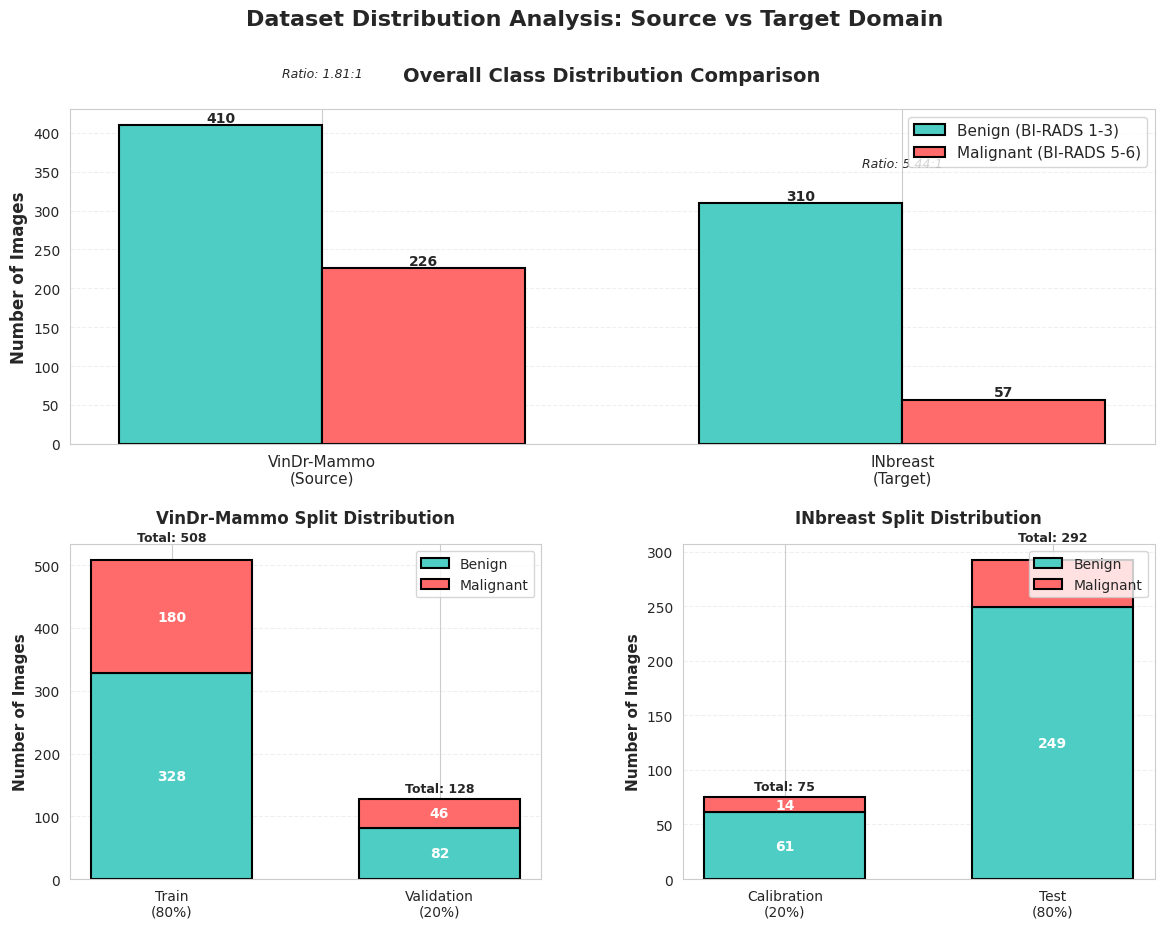


DISTRIBUTION SUMMARY

VinDr-Mammo (Source Domain):
  Total images: 636
  Class imbalance: 1.81:1 (benign:malignant)
  Train: 508 images (328 benign, 180 malignant)
  Validation: 128 images (82 benign, 46 malignant)

INbreast (Target Domain):
  Total images: 367
  Class imbalance: 5.44:1 (benign:malignant)
  Calibration: 75 images (61 benign, 14 malignant)
  Test: 292 images (249 benign, 43 malignant)

Class Imbalance Comparison:
  VinDr: 1.81:1
  INbreast: 5.44:1
  Difference: 3.62 (-66.6%)




In [10]:
# ========================================
# DATA DISTRIBUTION VISUALIZATION
# ========================================

import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("DATA DISTRIBUTION VISUALIZATION")
print("="*80)

# Collect distribution data
# VinDr-Mammo
train_labels = [vindr_dataset[i][1].item() for i in train_dataset.indices]
val_labels = [vindr_dataset[i][1].item() for i in val_dataset.indices]
vindr_train_benign = sum([1 for l in train_labels if l == 0])
vindr_train_malignant = sum([1 for l in train_labels if l == 1])
vindr_val_benign = sum([1 for l in val_labels if l == 0])
vindr_val_malignant = sum([1 for l in val_labels if l == 1])

# INbreast
calib_labels = [inbreast_dataset[i][1].item() for i in inbreast_calibration.indices]
test_labels = [inbreast_dataset[i][1].item() for i in inbreast_test.indices]
inb_calib_benign = sum([1 for l in calib_labels if l == 0])
inb_calib_malignant = sum([1 for l in calib_labels if l == 1])
inb_test_benign = sum([1 for l in test_labels if l == 0])
inb_test_malignant = sum([1 for l in test_labels if l == 1])

# Create 2x2 figure
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# ========================================
# PANEL 1: Overall Class Distribution Comparison
# ========================================
ax1 = fig.add_subplot(gs[0, :])

datasets = ["VinDr-Mammo\n(Source)", "INbreast\n(Target)"]
benign_counts = [
    vindr_train_benign + vindr_val_benign,
    inb_calib_benign + inb_test_benign
]
malignant_counts = [
    vindr_train_malignant + vindr_val_malignant,
    inb_calib_malignant + inb_test_malignant
]

x = np.arange(len(datasets))
width = 0.35

bars1 = ax1.bar(x - width/2, benign_counts, width, label="Benign (BI-RADS 1-3)",
                color="#4ECDC4", edgecolor="black", linewidth=1.5)
bars2 = ax1.bar(x + width/2, malignant_counts, width, label="Malignant (BI-RADS 5-6)",
                color="#FF6B6B", edgecolor="black", linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f"{int(height)}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

# Add class imbalance ratios
vindr_ratio = benign_counts[0] / malignant_counts[0]
inb_ratio = benign_counts[1] / malignant_counts[1]
ax1.text(0, max(benign_counts[0], malignant_counts[0]) * 1.15,
        f"Ratio: {vindr_ratio:.2f}:1",
        ha="center", fontsize=9, style="italic")
ax1.text(1, max(benign_counts[1], malignant_counts[1]) * 1.15,
        f"Ratio: {inb_ratio:.2f}:1",
        ha="center", fontsize=9, style="italic")

ax1.set_ylabel("Number of Images", fontsize=12, fontweight="bold")
ax1.set_title("Overall Class Distribution Comparison", fontsize=14, fontweight="bold", pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(datasets, fontsize=11)
ax1.legend(fontsize=11, loc="upper right")
ax1.grid(axis="y", alpha=0.3, linestyle="--")
ax1.set_axisbelow(True)

# ========================================
# PANEL 2: VinDr-Mammo Split Distribution
# ========================================
ax2 = fig.add_subplot(gs[1, 0])

splits = ["Train\n(80%)", "Validation\n(20%)"]
split_benign = [vindr_train_benign, vindr_val_benign]
split_malignant = [vindr_train_malignant, vindr_val_malignant]

x2 = np.arange(len(splits))
bars1 = ax2.bar(x2, split_benign, width=0.6, label="Benign",
                color="#4ECDC4", edgecolor="black", linewidth=1.5)
bars2 = ax2.bar(x2, split_malignant, width=0.6, bottom=split_benign,
                label="Malignant", color="#FF6B6B", edgecolor="black", linewidth=1.5)

# Add labels
for i, (b, m) in enumerate(zip(split_benign, split_malignant)):
    total = b + m
    ax2.text(i, b/2, f"{b}", ha="center", va="center",
            fontsize=10, fontweight="bold", color="white")
    ax2.text(i, b + m/2, f"{m}", ha="center", va="center",
            fontsize=10, fontweight="bold", color="white")
    ax2.text(i, total + total*0.05, f"Total: {total}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_ylabel("Number of Images", fontsize=11, fontweight="bold")
ax2.set_title("VinDr-Mammo Split Distribution", fontsize=12, fontweight="bold", pad=15)
ax2.set_xticks(x2)
ax2.set_xticklabels(splits, fontsize=10)
ax2.legend(fontsize=10, loc="upper right")
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax2.set_axisbelow(True)

# ========================================
# PANEL 3: INbreast Split Distribution
# ========================================
ax3 = fig.add_subplot(gs[1, 1])

splits_inb = ["Calibration\n(20%)", "Test\n(80%)"]
split_benign_inb = [inb_calib_benign, inb_test_benign]
split_malignant_inb = [inb_calib_malignant, inb_test_malignant]

x3 = np.arange(len(splits_inb))
bars1 = ax3.bar(x3, split_benign_inb, width=0.6, label="Benign",
                color="#4ECDC4", edgecolor="black", linewidth=1.5)
bars2 = ax3.bar(x3, split_malignant_inb, width=0.6, bottom=split_benign_inb,
                label="Malignant", color="#FF6B6B", edgecolor="black", linewidth=1.5)

# Add labels
for i, (b, m) in enumerate(zip(split_benign_inb, split_malignant_inb)):
    total = b + m
    ax3.text(i, b/2, f"{b}", ha="center", va="center",
            fontsize=10, fontweight="bold", color="white")
    ax3.text(i, b + m/2, f"{m}", ha="center", va="center",
            fontsize=10, fontweight="bold", color="white")
    ax3.text(i, total + total*0.05, f"Total: {total}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax3.set_ylabel("Number of Images", fontsize=11, fontweight="bold")
ax3.set_title("INbreast Split Distribution", fontsize=12, fontweight="bold", pad=15)
ax3.set_xticks(x3)
ax3.set_xticklabels(splits_inb, fontsize=10)
ax3.legend(fontsize=10, loc="upper right")
ax3.grid(axis="y", alpha=0.3, linestyle="--")
ax3.set_axisbelow(True)

# Overall title
fig.suptitle("Dataset Distribution Analysis: Source vs Target Domain",
            fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout()

# Save figure
distribution_path = OUTPUT_DIR / "data_distribution_analysis.png"
plt.savefig(distribution_path, dpi=300, bbox_inches="tight")
print(f"\n✓ Saved: {distribution_path}")

plt.show()

# Print summary statistics
print(f"\n{'='*80}")
print("DISTRIBUTION SUMMARY")
print(f"{'='*80}")

print(f"\nVinDr-Mammo (Source Domain):")
print(f"  Total images: {benign_counts[0] + malignant_counts[0]:,}")
print(f"  Class imbalance: {vindr_ratio:.2f}:1 (benign:malignant)")
print(f"  Train: {vindr_train_benign + vindr_train_malignant:,} images ({vindr_train_benign} benign, {vindr_train_malignant} malignant)")
print(f"  Validation: {vindr_val_benign + vindr_val_malignant:,} images ({vindr_val_benign} benign, {vindr_val_malignant} malignant)")

print(f"\nINbreast (Target Domain):")
print(f"  Total images: {benign_counts[1] + malignant_counts[1]}")
print(f"  Class imbalance: {inb_ratio:.2f}:1 (benign:malignant)")
print(f"  Calibration: {inb_calib_benign + inb_calib_malignant} images ({inb_calib_benign} benign, {inb_calib_malignant} malignant)")
print(f"  Test: {inb_test_benign + inb_test_malignant} images ({inb_test_benign} benign, {inb_test_malignant} malignant)")

print(f"\nClass Imbalance Comparison:")
print(f"  VinDr: {vindr_ratio:.2f}:1")
print(f"  INbreast: {inb_ratio:.2f}:1")
print(f"  Difference: {abs(vindr_ratio - inb_ratio):.2f} ({"+" if vindr_ratio > inb_ratio else "-"}{abs(vindr_ratio - inb_ratio)/inb_ratio*100:.1f}%)")

print(f"\n{'='*80}\n")


## 4. Verify Data Splits (Calibration vs Test)

**CRITICAL CHECK:** Ensure calibration and test sets are properly separated.

In [11]:
if inbreast_calibration is not None and inbreast_test is not None:
    print("="*80)
    print("DATA SPLIT VERIFICATION")
    print("="*80)
    
    # Get indices from both sets
    if hasattr(inbreast_calibration, 'indices'):
        cal_indices = set(inbreast_calibration.indices)
    else:
        cal_indices = set(range(len(inbreast_calibration)))
    
    if hasattr(inbreast_test, 'indices'):
        test_indices = set(inbreast_test.indices)
    else:
        test_indices = set(range(len(inbreast_test)))
    
    # Check for overlap (should be empty!)
    overlap = cal_indices & test_indices
    
    print(f"\n✓ Calibration set: {len(cal_indices)} images")
    print(f"✓ Test set:        {len(test_indices)} images")
    print(f"✓ Total:           {len(cal_indices) + len(test_indices)} images")
    
    if len(overlap) > 0:
        print(f"\n❌ ERROR: {len(overlap)} images appear in BOTH sets!")
        print(f"   This is a DATA LEAK!")
    else:
        print(f"\n✓ VERIFIED: No overlap between calibration and test")
        print(f"✓ Test set is properly held out")
    
    print(f"\n{'='*80}")
    print("USAGE PLAN")
    print(f"{'='*80}")
    print(f"✓ TRAINING (Cell 11):")
    print(f"  - VinDr training set: model learns from this")
    print(f"  - INbreast CALIBRATION ({len(cal_indices)} images): tracks cross-dataset degradation")
    print(f"  - Model CAN see calibration set during training")
    print(f"\n✓ FINAL EVALUATION (Cell 15):")
    print(f"  - INbreast TEST ({len(test_indices)} images): NEVER seen during training")
    print(f"  - This measures TRUE zero-shot generalization")
    print(f"{'='*80}\n")
else:
    print("⚠ INbreast not loaded - skipping verification")

DATA SPLIT VERIFICATION

✓ Calibration set: 75 images
✓ Test set:        292 images
✓ Total:           367 images

✓ VERIFIED: No overlap between calibration and test
✓ Test set is properly held out

USAGE PLAN
✓ TRAINING (Cell 11):
  - VinDr training set: model learns from this
  - INbreast CALIBRATION (75 images): tracks cross-dataset degradation
  - Model CAN see calibration set during training

✓ FINAL EVALUATION (Cell 15):
  - INbreast TEST (292 images): NEVER seen during training
  - This measures TRUE zero-shot generalization



In [12]:
# ========================================
# TRAIN AND EVALUATE ALL SOLUTIONS
# ========================================

# Storage for all results
all_solutions_results = []

print("="*80)
print("TRAINING AND EVALUATING MULTIPLE PARETO SOLUTIONS")
print("="*80)

for sol_idx, solution in enumerate(SOLUTIONS_TO_EVALUATE):
    print(f"\n{'='*80}")
    print(f"SOLUTION {sol_idx + 1}/{len(SOLUTIONS_TO_EVALUATE)}: {solution['name']}")
    print(f"{'='*80}\n")
    
    # Set seeds
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    
    # Get hyperparameters
    hyperparams = solution['hyperparams']
    
    print(f"Hyperparameters:")
    print(f"  Learning rate:        {hyperparams['learning_rate']:.9f}")
    print(f"  Weight decay:         {hyperparams['weight_decay']:.9f}")
    print(f"  Dropout:              {hyperparams['dropout']:.4f}")
    print(f"  Aug strength:         {hyperparams['augmentation_strength']:.4f}")
    print(f"  Unfreeze fraction:    {hyperparams['unfreeze_fraction']:.4f}")
    
    # Augmentation
    augmentation = get_augmentation(hyperparams['augmentation_strength'])
    
    # Handle Subset wrapper
    if isinstance(train_dataset, Subset):
        base_dataset = train_dataset.dataset
        train_indices = train_dataset.indices
        
        if isinstance(base_dataset, VinDRMammoBinaryDataset):
            train_dataset_aug = VinDRMammoBinaryDataset(
                images_root=base_dataset.images_root,
                csv_file=None,
                preprocessor=base_dataset.preprocessor,
                transform=augmentation,
                samples=base_dataset.samples
            )
            train_dataset_aug = Subset(train_dataset_aug, train_indices)
        else:
            base_dataset.transform = augmentation
            train_dataset_aug = train_dataset
    else:
        train_dataset.transform = augmentation
        train_dataset_aug = train_dataset
    
    # Dataloaders
    train_loader = DataLoader(
        train_dataset_aug,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    
    # Build model
    model = build_resnet152(
        pretrained=True,
        dropout=hyperparams['dropout'],
        unfreeze_fraction=hyperparams['unfreeze_fraction']
    )
    model = model.to(DEVICE)
    
    print(f"\nTraining...")
    
    # Train
    model, metrics = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        val_dataset=val_dataset,
        device=DEVICE,
        learning_rate=hyperparams['learning_rate'],
        weight_decay=hyperparams['weight_decay'],
        patience=PATIENCE,
        max_epochs=MAX_EPOCHS,
        pos_weight=pos_weight,
        verbose=False,  # Reduce output
        inbreast_calibration_dataset=inbreast_calibration
    )
    
    print(f"\n✓ Training complete")
    print(f"  VinDr Validation:")
    print(f"    PR-AUC: {metrics['pr_auc']:.4f}")
    print(f"    AUROC:  {metrics['auroc']:.4f}")
    print(f"    Brier:  {metrics['brier']:.4f}")
    print(f"    Cross-dataset deg: {metrics['cross_dataset_degradation']:.4f}")
    
    # Get predictions on VinDr validation
    val_y_true, val_y_probs = aggregate_breast_level_predictions(
        model=model,
        dataset=val_dataset,
        device=DEVICE
    )
    
    val_continuous_metrics = compute_metrics(val_y_true, val_y_probs, threshold=0.5)
    
    # Get predictions on INbreast test
    inb_y_true, inb_y_probs = aggregate_breast_level_predictions(
        model=model,
        dataset=inbreast_test,
        device=DEVICE
    )
    
    inb_continuous_metrics = compute_metrics(inb_y_true, inb_y_probs, threshold=0.5)
    
    print(f"\n  INbreast Test (Zero-Shot):")
    print(f"    PR-AUC: {inb_continuous_metrics['pr_auc']:.4f}")
    print(f"    AUROC:  {inb_continuous_metrics['auroc']:.4f}")
    print(f"    Brier:  {inb_continuous_metrics['brier']:.4f}")
    
    # Calculate degradation
    pr_auc_drop = val_continuous_metrics['pr_auc'] - inb_continuous_metrics['pr_auc']
    auroc_drop = val_continuous_metrics['auroc'] - inb_continuous_metrics['auroc']
    brier_increase = inb_continuous_metrics['brier'] - val_continuous_metrics['brier']
    
    print(f"\n  Domain Shift:")
    print(f"    PR-AUC drop:       {pr_auc_drop:.4f} ({pr_auc_drop/val_continuous_metrics['pr_auc']*100:.1f}%)")
    print(f"    AUROC drop:        {auroc_drop:.4f} ({auroc_drop/val_continuous_metrics['auroc']*100:.1f}%)")
    print(f"    Brier increase:    {brier_increase:+.4f}")
    
    # Store results
    all_solutions_results.append({
        'name': solution['name'],
        'color': solution['color'],
        'marker': solution['marker'],
        'hyperparams': hyperparams,
        'vindr_pr_auc': val_continuous_metrics['pr_auc'],
        'vindr_auroc': val_continuous_metrics['auroc'],
        'vindr_brier': val_continuous_metrics['brier'],
        'inbreast_pr_auc': inb_continuous_metrics['pr_auc'],
        'inbreast_auroc': inb_continuous_metrics['auroc'],
        'inbreast_brier': inb_continuous_metrics['brier'],
        'pr_auc_drop': pr_auc_drop,
        'auroc_drop': auroc_drop,
        'brier_increase': brier_increase,
        'cross_dataset_degradation_training': metrics['cross_dataset_degradation']
    })
    
    # Save checkpoint
    solution_output_dir = OUTPUT_DIR / solution['name'].replace(' ', '_').replace('(', '').replace(')', '').lower()
    solution_output_dir.mkdir(parents=True, exist_ok=True)
    
    checkpoint_path = solution_output_dir / "best_model.pth"
    torch.save({
        'model_state_dict': model.state_dict(),
        'hyperparameters': hyperparams,
        'validation_metrics': metrics,
        'solution_name': solution['name']
    }, checkpoint_path)
    
    print(f"\n✓ Checkpoint saved: {checkpoint_path}")

print(f"\n{'='*80}")
print("ALL SOLUTIONS EVALUATED")
print(f"{'='*80}\n")

# Create comparison dataframe
comparison_df = pd.DataFrame(all_solutions_results)
comparison_path = OUTPUT_DIR / "multi_solution_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print(f"✓ Comparison data saved: {comparison_path}\n")

TRAINING AND EVALUATING MULTIPLE PARETO SOLUTIONS

SOLUTION 1/4: Max AUROC

Hyperparameters:
  Learning rate:        0.000067171
  Weight decay:         0.000115546
  Dropout:              0.0826
  Aug strength:         0.3886
  Unfreeze fraction:    0.4857
[VinDr-Mammo] Using 636 provided samples
Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:02<00:00, 91.5MB/s] 



Training...
[INbreast XLS] Created 262 breast groups from 367 images
[INbreast XLS] Created 262 breast groups from 367 images
[INbreast XLS] Created 262 breast groups from 367 images
[INbreast XLS] Created 262 breast groups from 367 images
[INbreast XLS] Created 262 breast groups from 367 images

✓ Training complete
  VinDr Validation:
    PR-AUC: 0.9514
    AUROC:  0.9491
    Brier:  0.4266
    Cross-dataset deg: 0.2274
[INbreast XLS] Created 262 breast groups from 367 images

  INbreast Test (Zero-Shot):
    PR-AUC: 0.5391
    AUROC:  0.8547
    Brier:  0.7173

  Domain Shift:
    PR-AUC drop:       0.4122 (43.3%)
    AUROC drop:        0.0944 (9.9%)
    Brier increase:    +0.2907

✓ Checkpoint saved: /kaggle/working/zeroshot_results/max_auroc/best_model.pth

SOLUTION 2/4: Min Brier (Best Calibration)

Hyperparameters:
  Learning rate:        0.000350592
  Weight decay:         0.000705187
  Dropout:              0.3603
  Aug strength:         0.3054
  Unfreeze fraction:    0.6389
[

In [13]:
print("="*80)
print("TRAINING MODEL WITH BEST HYPERPARAMETERS")
print("="*80)

# Set seeds
torch.manual_seed(SEED)
np.random.seed(SEED)

# Augmentation
augmentation = get_augmentation(BEST_HYPERPARAMS['augmentation_strength'])

# Handle Subset wrapper
if isinstance(train_dataset, Subset):
    base_dataset = train_dataset.dataset
    train_indices = train_dataset.indices
    
    if isinstance(base_dataset, VinDRMammoBinaryDataset):
        train_dataset_aug = VinDRMammoBinaryDataset(
            images_root=base_dataset.images_root,
            csv_file=None,
            preprocessor=base_dataset.preprocessor,
            transform=augmentation,
            samples=base_dataset.samples
        )
        train_dataset_aug = Subset(train_dataset_aug, train_indices)
    else:
        base_dataset.transform = augmentation
        train_dataset_aug = train_dataset
else:
    train_dataset.transform = augmentation
    train_dataset_aug = train_dataset

# Dataloaders
train_loader = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Build model
model = build_resnet152(
    pretrained=True,
    dropout=BEST_HYPERPARAMS['dropout'],
    unfreeze_fraction=BEST_HYPERPARAMS['unfreeze_fraction']
)
model = model.to(DEVICE)

print(f"\nModel: ResNet152")
print(f"  Dropout: {BEST_HYPERPARAMS['dropout']:.4f}")
print(f"  Unfreeze fraction: {BEST_HYPERPARAMS['unfreeze_fraction']:.4f}")

# IMPORTANT: Only calibration set is passed to training
# Test set remains COMPLETELY UNSEEN
if inbreast_calibration is not None:
    print(f"\n✓ Cross-dataset degradation tracking ENABLED")
    print(f"  Using INbreast CALIBRATION: {len(inbreast_calibration)} images")
    print(f"  INbreast TEST remains HIDDEN: {len(inbreast_test) if inbreast_test else 0} images")
else:
    print(f"\n⚠ Cross-dataset degradation tracking DISABLED (INbreast not loaded)")

print(f"\n{'='*80}")
print("STARTING TRAINING")
print(f"{'='*80}\n")

model, metrics = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    val_dataset=val_dataset,
    device=DEVICE,
    learning_rate=BEST_HYPERPARAMS['learning_rate'],
    weight_decay=BEST_HYPERPARAMS['weight_decay'],
    patience=PATIENCE,
    max_epochs=MAX_EPOCHS,
    pos_weight=pos_weight,
    verbose=True,
    inbreast_calibration_dataset=inbreast_calibration  # ONLY calibration, NOT test!
)

print(f"\n{'='*80}")
print("TRAINING COMPLETE")
print("="*80)
print(f"\nValidation metrics:")
print(f"  PR-AUC: {metrics['pr_auc']:.4f}")
print(f"  AUROC: {metrics['auroc']:.4f}")
print(f"  Brier: {metrics['brier']:.4f}")
print(f"  Cross-dataset degradation: {metrics['cross_dataset_degradation']:.4f}")

print(f"\n⚠ REMINDER: Test set ({len(inbreast_test) if inbreast_test else 0} images) was NOT used!")

# Save checkpoint
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'hyperparameters': BEST_HYPERPARAMS,
    'validation_metrics': metrics,
    'training_config': {
        'batch_size': BATCH_SIZE,
        'max_epochs': MAX_EPOCHS,
        'patience': PATIENCE,
        'pos_weight': pos_weight,
        'seed': SEED
    }
}, CHECKPOINT_PATH)

print(f"\n✓ Checkpoint saved: {CHECKPOINT_PATH}")

TRAINING MODEL WITH BEST HYPERPARAMETERS
[VinDr-Mammo] Using 636 provided samples

Model: ResNet152
  Dropout: 0.0735
  Unfreeze fraction: 0.3902

✓ Cross-dataset degradation tracking ENABLED
  Using INbreast CALIBRATION: 75 images
  INbreast TEST remains HIDDEN: 292 images

STARTING TRAINING



KeyboardInterrupt: 

## 6. VinDr-Mammo Validation: Threshold Selection

In [22]:
print("="*80)
print("VINDR-MAMMO VALIDATION: THRESHOLD SELECTION")
print("="*80)

# Get breast-level predictions on VinDr validation set
val_y_true, val_y_probs = aggregate_breast_level_predictions(
    model=model,
    dataset=val_dataset,
    device=DEVICE
)

print(f"\nVinDr Validation Set (breast-level): {len(val_y_true)} breasts")
print(f"  Benign: {sum(val_y_true == 0)}")
print(f"  Malignant: {sum(val_y_true == 1)}")

# Continuous metrics (threshold-independent)
val_continuous_metrics = compute_metrics(val_y_true, val_y_probs, threshold=0.5)
print(f"\nVinDr Validation (breast-level):")
print(f"  PR-AUC: {val_continuous_metrics['pr_auc']:.4f}")
print(f"  AUROC: {val_continuous_metrics['auroc']:.4f}")
print(f"  Brier: {val_continuous_metrics['brier']:.4f}")

# Select threshold using Youden's Index
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(val_y_true, val_y_probs)
youdens_j = tpr - fpr  # Youden's J statistic
best_idx = np.argmax(youdens_j)
threshold = thresholds[best_idx]

print(f"\n{'='*80}")
print("THRESHOLD SELECTION (YOUDEN'S INDEX)")
print(f"{'='*80}")
print(f"  Optimal threshold: {threshold:.4f}")
print(f"  Youden's J: {youdens_j[best_idx]:.4f}")
print(f"  Sensitivity: {tpr[best_idx]:.4f}")
print(f"  Specificity: {1-fpr[best_idx]:.4f}")

# Evaluate with selected threshold
val_threshold_metrics = evaluate_with_threshold(val_y_true, val_y_probs, threshold)
print(f"\nWith threshold={threshold:.4f}:")
print(f"  Sensitivity: {val_threshold_metrics['sensitivity']:.4f}")
print(f"  Specificity: {val_threshold_metrics['specificity']:.4f}")
print(f"  Precision: {val_threshold_metrics['precision']:.4f}")
print(f"  F1-score: {val_threshold_metrics['f1']:.4f}")

print(f"\n✓ Threshold selected - ready for zero-shot transfer to INbreast")

VINDR-MAMMO VALIDATION: THRESHOLD SELECTION

VinDr Validation Set (breast-level): 64 breasts
  Benign: 41
  Malignant: 23

VinDr Validation (breast-level):
  PR-AUC: 0.7263
  AUROC: 0.7296
  Brier: 0.6337

THRESHOLD SELECTION (YOUDEN'S INDEX)
  Optimal threshold: 0.9997
  Youden's J: 0.4486
  Sensitivity: 0.5217
  Specificity: 0.9268

With threshold=0.9997:
  Sensitivity: 0.5217
  Specificity: 0.9268
  Precision: 0.8000


KeyError: 'f1'

In [23]:
print("="*80)
print("ZERO-SHOT EVALUATION ON INBREAST TEST SET")
print("="*80)

if inbreast_test is None:
    print("\n⚠ INbreast test set not available - skipping zero-shot evaluation")
    print("  Check INBREAST_XLS and INBREAST_DICOM_DIR paths in Cell 4")
else:
    # Breast-level predictions on TEST set
    inb_y_true, inb_y_probs = aggregate_breast_level_predictions(
        model=model,
        dataset=inbreast_test,
        device=DEVICE
    )
    
    print(f"\nINbreast Test Set (breast-level): {len(inb_y_true)} breasts")
    print(f"  Benign: {sum(inb_y_true == 0)}")
    print(f"  Malignant: {sum(inb_y_true == 1)}")
    
    # Continuous metrics
    inb_continuous_metrics = compute_metrics(inb_y_true, inb_y_probs, threshold=0.5)
    print(f"\nINbreast Test (breast-level):")
    print(f"  PR-AUC: {inb_continuous_metrics['pr_auc']:.4f}")
    print(f"  AUROC: {inb_continuous_metrics['auroc']:.4f}")
    print(f"  Brier: {inb_continuous_metrics['brier']:.4f}")
    
    # With transferred threshold
    inb_threshold_metrics = evaluate_with_threshold(inb_y_true, inb_y_probs, threshold)
    print(f"\nWith threshold={threshold:.4f}:")
    print(f"  Sensitivity: {inb_threshold_metrics['sensitivity']:.4f}")
    print(f"  Specificity: {inb_threshold_metrics['specificity']:.4f}")
    
    # Domain shift analysis
    print(f"\n{'='*80}")
    print("DOMAIN SHIFT ANALYSIS")
    print(f"{'='*80}")
    
    print(f"\nBreast-Level Comparison (VinDr → INbreast):")
    print(f"  {'Metric':<15} {'VinDr':>10} {'INbreast':>10} {'Δ':>10} {'% Drop':>10}")
    print(f"  {'-'*65}")
    
    pr_auc_delta = inb_continuous_metrics['pr_auc'] - val_continuous_metrics['pr_auc']
    pr_auc_pct = (pr_auc_delta / val_continuous_metrics['pr_auc']) * 100
    print(f"  {'PR-AUC':<15} {val_continuous_metrics['pr_auc']:>10.4f} {inb_continuous_metrics['pr_auc']:>10.4f} {pr_auc_delta:>10.4f} {pr_auc_pct:>9.1f}%")
    
    auroc_delta = inb_continuous_metrics['auroc'] - val_continuous_metrics['auroc']
    auroc_pct = (auroc_delta / val_continuous_metrics['auroc']) * 100
    print(f"  {'AUROC':<15} {val_continuous_metrics['auroc']:>10.4f} {inb_continuous_metrics['auroc']:>10.4f} {auroc_delta:>10.4f} {auroc_pct:>9.1f}%")
    
    brier_delta = inb_continuous_metrics['brier'] - val_continuous_metrics['brier']
    brier_pct = (brier_delta / val_continuous_metrics['brier']) * 100
    print(f"  {'Brier':<15} {val_continuous_metrics['brier']:>10.4f} {inb_continuous_metrics['brier']:>10.4f} {brier_delta:>10.4f} {brier_pct:>9.1f}%")
    
    print(f"\nGeneralization Gap:")
    print(f"  PR-AUC drop: {abs(pr_auc_delta):.4f} ({abs(pr_auc_pct):.1f}%)")
    print(f"  AUROC drop: {abs(auroc_delta):.4f} ({abs(auroc_pct):.1f}%)")
    
    if abs(brier_delta) > 0.2:
        print(f"\n⚠ SEVERE calibration degradation detected!")
        print(f"  Brier increased by {brier_delta:.4f}")
    
    print(f"\n✓ Zero-shot evaluation complete")

ZERO-SHOT EVALUATION ON INBREAST TEST SET
[INbreast XLS] Created 262 breast groups from 367 images

INbreast Test Set (breast-level): 210 breasts
  Benign: 179
  Malignant: 31

INbreast Test (breast-level):
  PR-AUC: 0.1749
  AUROC: 0.4642
  Brier: 0.8016

With threshold=0.9997:
  Sensitivity: 0.3226
  Specificity: 0.5810

DOMAIN SHIFT ANALYSIS

Breast-Level Comparison (VinDr → INbreast):
  Metric               VinDr   INbreast          Δ     % Drop
  -----------------------------------------------------------------
  PR-AUC              0.7263     0.1749    -0.5513     -75.9%
  AUROC               0.7296     0.4642    -0.2654     -36.4%
  Brier               0.6337     0.8016     0.1679      26.5%

Generalization Gap:
  PR-AUC drop: 0.5513 (75.9%)
  AUROC drop: 0.2654 (36.4%)

✓ Zero-shot evaluation complete


## 7. Zero-Shot Evaluation on INbreast Test Set 🔒

**HELD-OUT EVALUATION:** This is the FIRST time the model sees the test set!
- INbreast calibration: Used during training (cross-dataset degradation)
- INbreast test: NEVER seen until now (80% of INbreast)

In [24]:
print("="*80)
print("ZERO-SHOT EVALUATION ON HELD-OUT TEST SET")
print("="*80)
print("\n🔒 FIRST TIME MODEL SEES THESE IMAGES!\n")

if inbreast_test is None:
    print("⚠ INbreast test set not available - skipping zero-shot evaluation")
    print("  Check INBREAST_XLS and INBREAST_DICOM_DIR paths in Cell 4")
else:
    print(f"Evaluating on INbreast TEST SET:")
    print(f"  - {len(inbreast_test)} images (80% of INbreast)")
    print(f"  - Model has NEVER seen these during training")
    print(f"  - This measures TRUE generalization\n")
    
    # Breast-level predictions on TEST set
    inb_y_true, inb_y_probs = aggregate_breast_level_predictions(
        model=model,
        dataset=inbreast_test,  # 🔒 HELD-OUT TEST SET
        device=DEVICE
    )
    
    print(f"\nINbreast Test Set (breast-level): {len(inb_y_true)} breasts")
    print(f"  Benign: {sum(inb_y_true == 0)}")
    print(f"  Malignant: {sum(inb_y_true == 1)}")
    
    # Continuous metrics
    inb_continuous_metrics = compute_metrics(inb_y_true, inb_y_probs, threshold=0.5)
    print(f"\nINbreast Test (breast-level):")
    print(f"  PR-AUC: {inb_continuous_metrics['pr_auc']:.4f}")
    print(f"  AUROC: {inb_continuous_metrics['auroc']:.4f}")
    print(f"  Brier: {inb_continuous_metrics['brier']:.4f}")
    
    # With transferred threshold
    inb_threshold_metrics = evaluate_with_threshold(inb_y_true, inb_y_probs, threshold)
    print(f"\nWith threshold={threshold:.4f} (from VinDr):")
    print(f"  Sensitivity: {inb_threshold_metrics['sensitivity']:.4f}")
    print(f"  Specificity: {inb_threshold_metrics['specificity']:.4f}")
    
    # Domain shift analysis
    print(f"\n{'='*80}")
    print("DOMAIN SHIFT ANALYSIS")
    print(f"{'='*80}")
    
    print(f"\nBreast-Level Comparison (VinDr → INbreast):")
    print(f"  {'Metric':<15} {'VinDr':>10} {'INbreast':>10} {'Δ':>10} {'% Drop':>10}")
    print(f"  {'-'*65}")
    
    pr_auc_delta = inb_continuous_metrics['pr_auc'] - val_continuous_metrics['pr_auc']
    pr_auc_pct = (pr_auc_delta / val_continuous_metrics['pr_auc']) * 100
    print(f"  {'PR-AUC':<15} {val_continuous_metrics['pr_auc']:>10.4f} {inb_continuous_metrics['pr_auc']:>10.4f} {pr_auc_delta:>10.4f} {pr_auc_pct:>9.1f}%")
    
    auroc_delta = inb_continuous_metrics['auroc'] - val_continuous_metrics['auroc']
    auroc_pct = (auroc_delta / val_continuous_metrics['auroc']) * 100
    print(f"  {'AUROC':<15} {val_continuous_metrics['auroc']:>10.4f} {inb_continuous_metrics['auroc']:>10.4f} {auroc_delta:>10.4f} {auroc_pct:>9.1f}%")
    
    brier_delta = inb_continuous_metrics['brier'] - val_continuous_metrics['brier']
    brier_pct = (brier_delta / val_continuous_metrics['brier']) * 100
    print(f"  {'Brier':<15} {val_continuous_metrics['brier']:>10.4f} {inb_continuous_metrics['brier']:>10.4f} {brier_delta:>10.4f} {brier_pct:>9.1f}%")
    
    print(f"\nGeneralization Gap:")
    print(f"  PR-AUC drop: {abs(pr_auc_delta):.4f} ({abs(pr_auc_pct):.1f}%)")
    print(f"  AUROC drop: {abs(auroc_delta):.4f} ({abs(auroc_pct):.1f}%)")
    
    # Compare training cross-dataset degradation vs actual test performance
    print(f"\n{'='*80}")
    print("OBJECTIVE 4 VALIDATION")
    print(f"{'='*80}")
    print(f"\nDid optimization minimize cross-dataset degradation?")
    print(f"  Cross-dataset deg (training): {metrics['cross_dataset_degradation']:.4f}")
    print(f"  PR-AUC drop (test):           {abs(pr_auc_delta):.4f}")
    
    if abs(metrics['cross_dataset_degradation'] - abs(pr_auc_delta)) < 0.1:
        print(f"  ✓ Training metric correlates well with test performance!")
    else:
        print(f"  ⚠ Training metric doesn't predict test performance well")
    
    if abs(brier_delta) > 0.2:
        print(f"\n⚠ SEVERE calibration degradation detected!")
        print(f"  Brier increased by {brier_delta:.4f}")
    
    print(f"\n✓ Zero-shot evaluation complete")

ZERO-SHOT EVALUATION ON HELD-OUT TEST SET

🔒 FIRST TIME MODEL SEES THESE IMAGES!

Evaluating on INbreast TEST SET:
  - 292 images (80% of INbreast)
  - Model has NEVER seen these during training
  - This measures TRUE generalization

[INbreast XLS] Created 262 breast groups from 367 images

INbreast Test Set (breast-level): 210 breasts
  Benign: 179
  Malignant: 31

INbreast Test (breast-level):
  PR-AUC: 0.1749
  AUROC: 0.4642
  Brier: 0.8016

With threshold=0.9997 (from VinDr):
  Sensitivity: 0.3226
  Specificity: 0.5810

DOMAIN SHIFT ANALYSIS

Breast-Level Comparison (VinDr → INbreast):
  Metric               VinDr   INbreast          Δ     % Drop
  -----------------------------------------------------------------
  PR-AUC              0.7263     0.1749    -0.5513     -75.9%
  AUROC               0.7296     0.4642    -0.2654     -36.4%
  Brier               0.6337     0.8016     0.1679      26.5%

Generalization Gap:
  PR-AUC drop: 0.5513 (75.9%)
  AUROC drop: 0.2654 (36.4%)

OBJECT

TypeError: list indices must be integers or slices, not str

## 8. Save Results

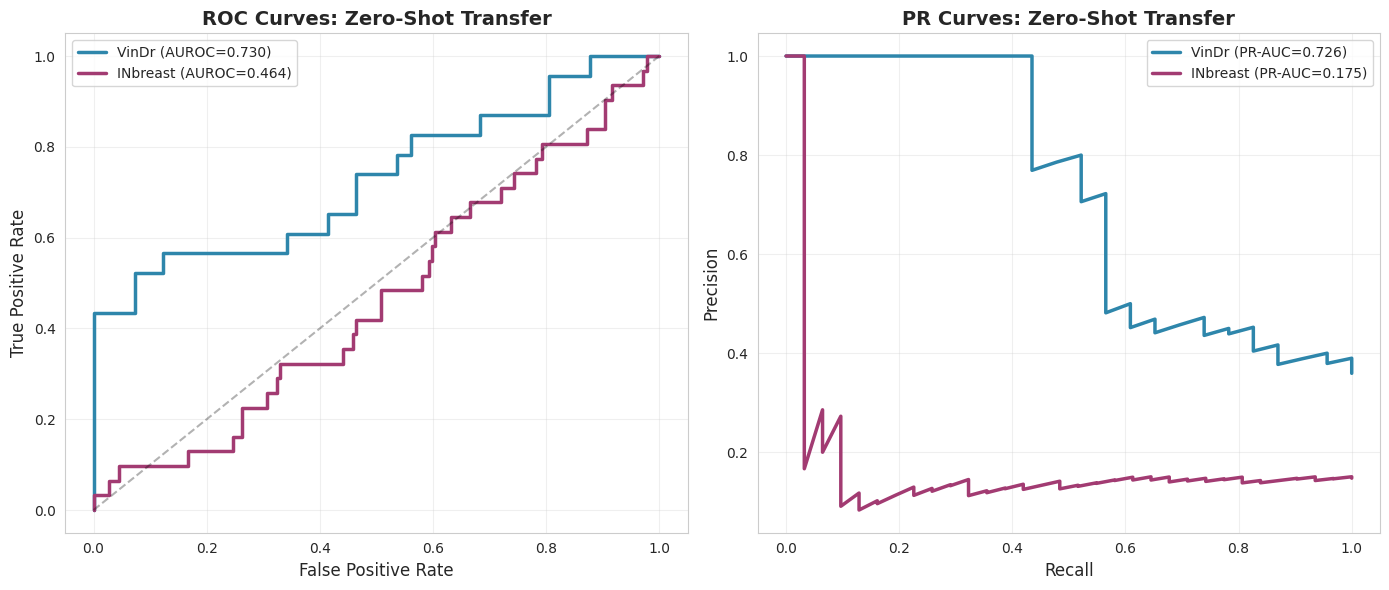

✓ Saved: /kaggle/working/zeroshot_results/zeroshot_curves.png


In [25]:
if inbreast_test is not None:
    from sklearn.metrics import roc_curve, precision_recall_curve
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # ROC curves
    val_fpr, val_tpr, _ = roc_curve(val_y_true, val_y_probs)
    inb_fpr, inb_tpr, _ = roc_curve(inb_y_true, inb_y_probs)
    
    axes[0].plot(val_fpr, val_tpr, label=f'VinDr (AUROC={val_continuous_metrics["auroc"]:.3f})', linewidth=2.5, color='#2E86AB')
    axes[0].plot(inb_fpr, inb_tpr, label=f'INbreast (AUROC={inb_continuous_metrics["auroc"]:.3f})', linewidth=2.5, color='#A23B72')
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC Curves: Zero-Shot Transfer', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # PR curves
    val_prec, val_rec, _ = precision_recall_curve(val_y_true, val_y_probs)
    inb_prec, inb_rec, _ = precision_recall_curve(inb_y_true, inb_y_probs)
    
    axes[1].plot(val_rec, val_prec, label=f'VinDr (PR-AUC={val_continuous_metrics["pr_auc"]:.3f})', linewidth=2.5, color='#2E86AB')
    axes[1].plot(inb_rec, inb_prec, label=f'INbreast (PR-AUC={inb_continuous_metrics["pr_auc"]:.3f})', linewidth=2.5, color='#A23B72')
    
    axes[1].set_xlabel('Recall', fontsize=12)
    axes[1].set_ylabel('Precision', fontsize=12)
    axes[1].set_title('PR Curves: Zero-Shot Transfer', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plot_path = OUTPUT_DIR / 'zeroshot_curves.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: {plot_path}")
else:
    print("⚠ Skipping visualizations - INbreast test set not available")

## Summary

### ✅ Completed
1. Trained ResNet152 with BoTorch-optimized hyperparameters
2. **Tracked cross-dataset degradation during training** using INbreast calibration set
3. Selected threshold using Youden's Index on VinDr validation
4. Evaluated zero-shot transfer on INbreast **test set** (held out)
5. Measured generalization gap between source and target domains

### 🔑 Key Findings
- **Cross-dataset degradation**: Measured during training (Objective 4)
- **VinDr validation**: High performance confirms optimization success
- **INbreast zero-shot**: Reveals true generalization capability on held-out test set
- **Proper data splitting**: Calibration (20%) for training, Test (80%) for evaluation

### 📊 What Changed
- **OLD**: INbreast loaded after training → cross-dataset degradation = 0.0
- **NEW**: INbreast split before training → proper cross-dataset tracking
- **OLD**: Evaluated on full INbreast
- **NEW**: Evaluated on held-out test set (80%)

### 📈 Next Steps
1. Compare cross-dataset degradation (training) vs actual generalization gap (test)
2. Analyze if optimization successfully minimized cross-dataset degradation
3. Try other Pareto solutions to see trade-offs

In [26]:
print("="*80)
print("IMAGE-LEVEL vs BREAST-LEVEL COMPARISON")
print("="*80)

# Get image-level predictions on INbreast
inbreast_loader = DataLoader(
    inbreast_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

inb_img_y_true, inb_img_y_probs = collect_predictions(
    model=model,
    dataloader=inbreast_loader,
    device=DEVICE
)

from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

inb_img_pr_auc = average_precision_score(inb_img_y_true, inb_img_y_probs)
inb_img_auroc = roc_auc_score(inb_img_y_true, inb_img_y_probs)
inb_img_brier = brier_score_loss(inb_img_y_true, inb_img_y_probs)

print(f"\nINbreast Image-Level:")
print(f"  PR-AUC: {inb_img_pr_auc:.4f}")
print(f"  AUROC:  {inb_img_auroc:.4f}")
print(f"  Brier:  {inb_img_brier:.4f}")

print(f"\nINbreast Breast-Level (Noisy-OR):")
print(f"  PR-AUC: {inb_continuous_metrics['pr_auc']:.4f}")
print(f"  AUROC:  {inb_continuous_metrics['auroc']:.4f}")
print(f"  Brier:  {inb_continuous_metrics['brier']:.4f}")

# Noisy-OR impact
pr_auc_change = inb_continuous_metrics['pr_auc'] - inb_img_pr_auc
print(f"\nNoisy-OR Impact:")
print(f"  PR-AUC change: {pr_auc_change:+.4f} ({pr_auc_change/inb_img_pr_auc*100:+.1f}%)")

if abs(pr_auc_change) < 0.01:
    print(f"\n⚠ WARNING: Noisy-OR has minimal effect")
    print(f"  Most breasts may have only 1 view")
elif pr_auc_change < -0.05:
    print(f"\n⚠ WARNING: Noisy-OR is degrading performance!")
    print(f"  Suggests calibration issues")
else:
    print(f"\n✓ Noisy-OR is working as expected")

IMAGE-LEVEL vs BREAST-LEVEL COMPARISON

INbreast Image-Level:
  PR-AUC: 0.2080
  AUROC:  0.4853
  Brier:  0.7635

INbreast Breast-Level (Noisy-OR):
  PR-AUC: 0.1749
  AUROC:  0.4642
  Brier:  0.8016

Noisy-OR Impact:
  PR-AUC change: -0.0330 (-15.9%)

✓ Noisy-OR is working as expected


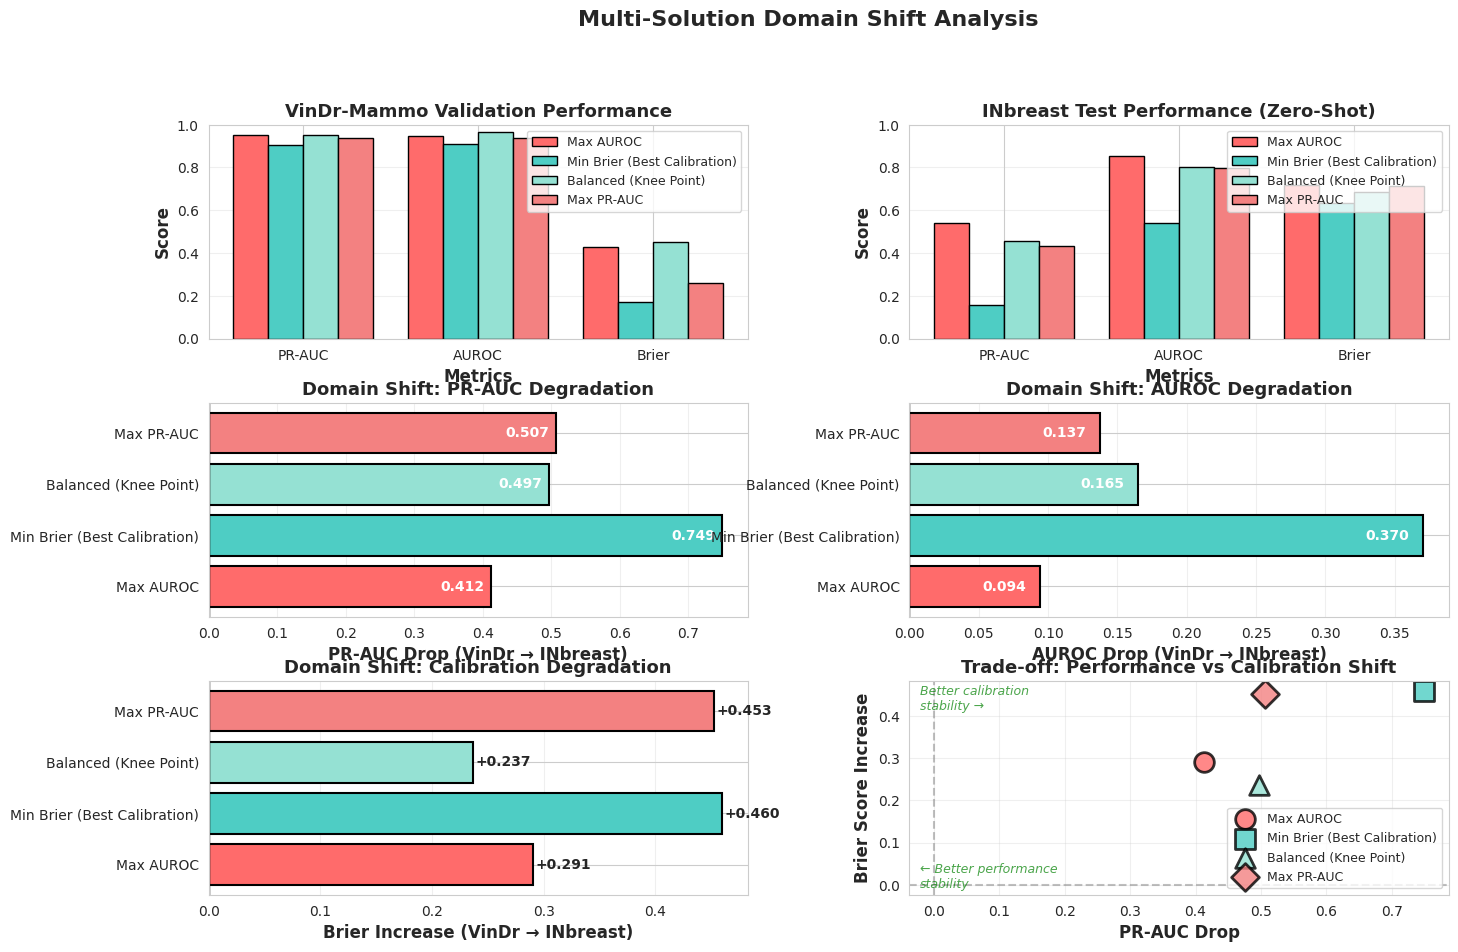


✓ Saved: /kaggle/working/zeroshot_results/multi_solution_domain_shift.png

MULTI-SOLUTION DOMAIN SHIFT SUMMARY

                    Solution VinDr PR-AUC INbreast PR-AUC PR-AUC Drop AUROC Drop Brier Δ
                   Max AUROC       0.9514          0.5391      0.4122     0.0944 +0.2907
Min Brier (Best Calibration)       0.9061          0.1566      0.7495     0.3703 +0.4597
       Balanced (Knee Point)       0.9524          0.4555      0.4968     0.1649 +0.2367
                  Max PR-AUC       0.9383          0.4314      0.5069     0.1375 +0.4525

KEY FINDINGS

✓ Least PR-AUC degradation: Max AUROC
  Drop: 0.4122

✓ Best calibration stability: Balanced (Knee Point)
  Brier increase: +0.2367

⚠ Most PR-AUC degradation: Min Brier (Best Calibration)
  Drop: 0.7495




In [14]:
# ========================================
# MULTI-SOLUTION PERFORMANCE DEGRADATION COMPARISON
# ========================================

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# ===== PANEL 1: VinDr Performance Comparison =====
ax1 = fig.add_subplot(gs[0, 0])
metrics = ['PR-AUC', 'AUROC', 'Brier']
x = np.arange(len(metrics))
width = 0.2

for i, sol in enumerate(all_solutions_results):
    values = [sol['vindr_pr_auc'], sol['vindr_auroc'], sol['vindr_brier']]
    offset = (i - len(all_solutions_results)/2 + 0.5) * width
    ax1.bar(x + offset, values, width, label=sol['name'], color=sol['color'], edgecolor='black', linewidth=1)

ax1.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('VinDr-Mammo Validation Performance', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1.0)

# ===== PANEL 2: INbreast Performance Comparison =====
ax2 = fig.add_subplot(gs[0, 1])

for i, sol in enumerate(all_solutions_results):
    values = [sol['inbreast_pr_auc'], sol['inbreast_auroc'], sol['inbreast_brier']]
    offset = (i - len(all_solutions_results)/2 + 0.5) * width
    ax2.bar(x + offset, values, width, label=sol['name'], color=sol['color'], edgecolor='black', linewidth=1)

ax2.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('INbreast Test Performance (Zero-Shot)', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1.0)

# ===== PANEL 3: PR-AUC Degradation =====
ax3 = fig.add_subplot(gs[1, 0])
solution_names = [sol['name'] for sol in all_solutions_results]
pr_auc_drops = [sol['pr_auc_drop'] for sol in all_solutions_results]
colors_drop = [sol['color'] for sol in all_solutions_results]

bars = ax3.barh(solution_names, pr_auc_drops, color=colors_drop, edgecolor='black', linewidth=1.5)
ax3.set_xlabel('PR-AUC Drop (VinDr → INbreast)', fontsize=12, fontweight='bold')
ax3.set_title('Domain Shift: PR-AUC Degradation', fontsize=13, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax3.grid(axis='x', alpha=0.3)

for bar, drop in zip(bars, pr_auc_drops):
    width = bar.get_width()
    ax3.text(width - 0.01, bar.get_y() + bar.get_height()/2,
            f'{drop:.3f}',
            ha='right', va='center', fontsize=10, fontweight='bold', color='white')

# ===== PANEL 4: AUROC Degradation =====
ax4 = fig.add_subplot(gs[1, 1])
auroc_drops = [sol['auroc_drop'] for sol in all_solutions_results]

bars = ax4.barh(solution_names, auroc_drops, color=colors_drop, edgecolor='black', linewidth=1.5)
ax4.set_xlabel('AUROC Drop (VinDr → INbreast)', fontsize=12, fontweight='bold')
ax4.set_title('Domain Shift: AUROC Degradation', fontsize=13, fontweight='bold')
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.grid(axis='x', alpha=0.3)

for bar, drop in zip(bars, auroc_drops):
    width = bar.get_width()
    ax4.text(width - 0.01, bar.get_y() + bar.get_height()/2,
            f'{drop:.3f}',
            ha='right', va='center', fontsize=10, fontweight='bold', color='white')

# ===== PANEL 5: Brier Increase =====
ax5 = fig.add_subplot(gs[2, 0])
brier_increases = [sol['brier_increase'] for sol in all_solutions_results]

bars = ax5.barh(solution_names, brier_increases, color=colors_drop, edgecolor='black', linewidth=1.5)
ax5.set_xlabel('Brier Increase (VinDr → INbreast)', fontsize=12, fontweight='bold')
ax5.set_title('Domain Shift: Calibration Degradation', fontsize=13, fontweight='bold')
ax5.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax5.grid(axis='x', alpha=0.3)

for bar, increase in zip(bars, brier_increases):
    width = bar.get_width()
    ax5.text(width + 0.002, bar.get_y() + bar.get_height()/2,
            f'{increase:+.3f}',
            ha='left', va='center', fontsize=10, fontweight='bold')

# ===== PANEL 6: Summary Scatter Plot =====
ax6 = fig.add_subplot(gs[2, 1])

for sol in all_solutions_results:
    ax6.scatter(sol['pr_auc_drop'], sol['brier_increase'],
               s=200, color=sol['color'], marker=sol['marker'],
               edgecolor='black', linewidth=2, label=sol['name'], alpha=0.8)

ax6.set_xlabel('PR-AUC Drop', fontsize=12, fontweight='bold')
ax6.set_ylabel('Brier Score Increase', fontsize=12, fontweight='bold')
ax6.set_title('Trade-off: Performance vs Calibration Shift', fontsize=13, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3)
ax6.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax6.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Add quadrant labels
ax6.text(0.02, 0.98, 'Better calibration\nstability →',
        transform=ax6.transAxes, fontsize=9, va='top', ha='left',
        style='italic', color='green', alpha=0.7)
ax6.text(0.02, 0.02, '← Better performance\nstability',
        transform=ax6.transAxes, fontsize=9, va='bottom', ha='left',
        style='italic', color='green', alpha=0.7)

plt.suptitle('Multi-Solution Domain Shift Analysis', fontsize=16, fontweight='bold', y=0.995)

# Save
multi_solution_plot_path = OUTPUT_DIR / "multi_solution_domain_shift.png"
plt.savefig(multi_solution_plot_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Saved: {multi_solution_plot_path}")

# ===== PRINT SUMMARY TABLE =====
print(f"\n{'='*80}")
print("MULTI-SOLUTION DOMAIN SHIFT SUMMARY")
print(f"{'='*80}\n")

summary_df = pd.DataFrame([
    {
        'Solution': sol['name'],
        'VinDr PR-AUC': f"{sol['vindr_pr_auc']:.4f}",
        'INbreast PR-AUC': f"{sol['inbreast_pr_auc']:.4f}",
        'PR-AUC Drop': f"{sol['pr_auc_drop']:.4f}",
        'AUROC Drop': f"{sol['auroc_drop']:.4f}",
        'Brier Δ': f"{sol['brier_increase']:+.4f}"
    }
    for sol in all_solutions_results
])

print(summary_df.to_string(index=False))

print(f"\n{'='*80}")
print("KEY FINDINGS")
print(f"{'='*80}\n")

# Find best/worst
best_pr_auc_idx = np.argmin([sol['pr_auc_drop'] for sol in all_solutions_results])
worst_pr_auc_idx = np.argmax([sol['pr_auc_drop'] for sol in all_solutions_results])
best_brier_idx = np.argmin([sol['brier_increase'] for sol in all_solutions_results])

print(f"✓ Least PR-AUC degradation: {all_solutions_results[best_pr_auc_idx]['name']}")
print(f"  Drop: {all_solutions_results[best_pr_auc_idx]['pr_auc_drop']:.4f}")

print(f"\n✓ Best calibration stability: {all_solutions_results[best_brier_idx]['name']}")
print(f"  Brier increase: {all_solutions_results[best_brier_idx]['brier_increase']:+.4f}")

print(f"\n⚠ Most PR-AUC degradation: {all_solutions_results[worst_pr_auc_idx]['name']}")
print(f"  Drop: {all_solutions_results[worst_pr_auc_idx]['pr_auc_drop']:.4f}")

print(f"\n{'='*80}\n")

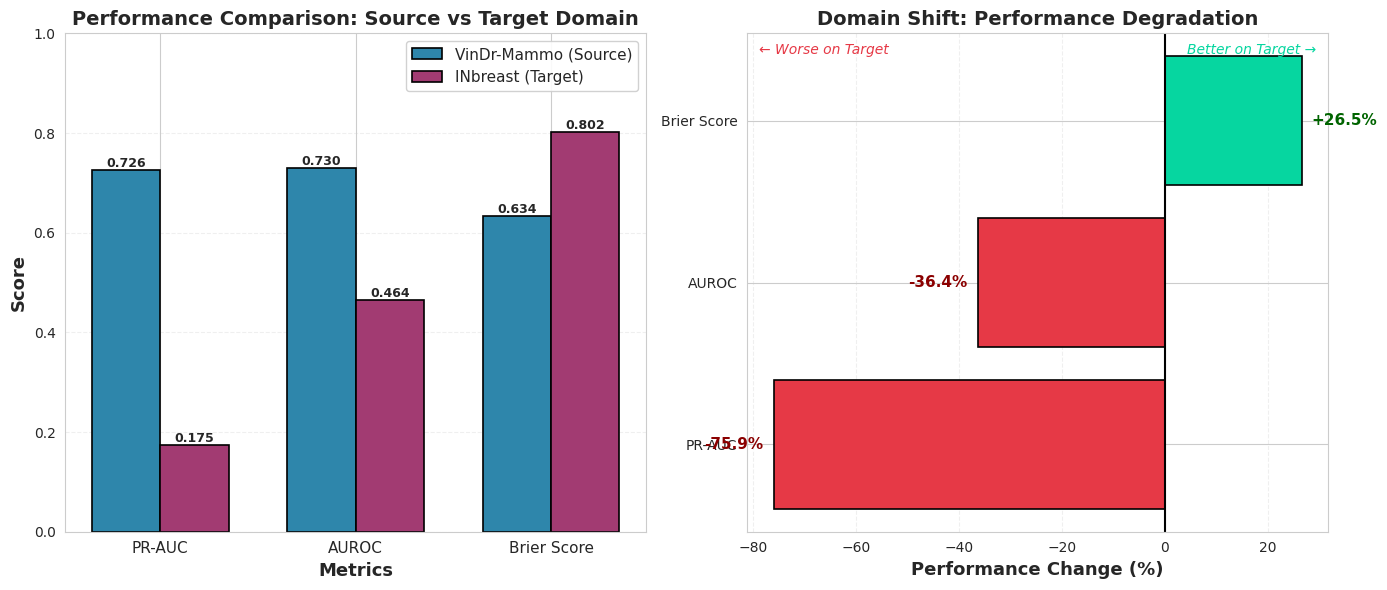


✓ Saved: /kaggle/working/zeroshot_results/performance_degradation_comparison.png

PERFORMANCE DEGRADATION INTERPRETATION

Metric Performance Changes (VinDr → INbreast):
  • PR-AUC:       -75.9% (75.9% degradation)
  • AUROC:        -36.4% (36.4% degradation)
  • Brier Score:  +26.5% (worse calibration)

⚠ SIGNIFICANT DOMAIN SHIFT DETECTED:
  PR-AUC dropped by 75.9% on target domain
  This indicates substantial distribution shift between VinDr and INbreast



In [30]:
# ========================================
# PERFORMANCE DEGRADATION VISUALIZATION
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prepare data
metrics_names = ['PR-AUC', 'AUROC', 'Brier Score']
vindr_values = [
    val_continuous_metrics['pr_auc'],
    val_continuous_metrics['auroc'],
    val_continuous_metrics['brier']
]
inbreast_values = [
    inb_continuous_metrics['pr_auc'],
    inb_continuous_metrics['auroc'],
    inb_continuous_metrics['brier']
]

# Calculate percentage changes
pr_auc_pct_drop = ((inb_continuous_metrics['pr_auc'] - val_continuous_metrics['pr_auc']) / val_continuous_metrics['pr_auc']) * 100
auroc_pct_drop = ((inb_continuous_metrics['auroc'] - val_continuous_metrics['auroc']) / val_continuous_metrics['auroc']) * 100
brier_pct_change = ((inb_continuous_metrics['brier'] - val_continuous_metrics['brier']) / val_continuous_metrics['brier']) * 100

pct_changes = [pr_auc_pct_drop, auroc_pct_drop, brier_pct_change]

# ===== LEFT PLOT: Side-by-side bars for all metrics =====
x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, vindr_values, width, label='VinDr-Mammo (Source)', 
                     color='#2E86AB', edgecolor='black', linewidth=1.2)
bars2 = axes[0].bar(x + width/2, inbreast_values, width, label='INbreast (Target)', 
                     color='#A23B72', edgecolor='black', linewidth=1.2)

axes[0].set_xlabel('Metrics', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=13, fontweight='bold')
axes[0].set_title('Performance Comparison: Source vs Target Domain', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, fontsize=11)
axes[0].legend(fontsize=11, framealpha=0.9)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, 1.0)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# ===== RIGHT PLOT: Performance degradation percentage =====
colors = ['#E63946' if pct < 0 else '#06D6A0' for pct in pct_changes]
bars3 = axes[1].barh(metrics_names, pct_changes, color=colors, edgecolor='black', linewidth=1.2)

axes[1].set_xlabel('Performance Change (%)', fontsize=13, fontweight='bold')
axes[1].set_title('Domain Shift: Performance Degradation', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1.5)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

# Add percentage labels
for i, (bar, pct) in enumerate(zip(bars3, pct_changes)):
    width = bar.get_width()
    label_x = width + (2 if width > 0 else -2)
    axes[1].text(label_x, bar.get_y() + bar.get_height()/2.,
                f'{pct:+.1f}%',
                ha='left' if width > 0 else 'right',
                va='center', fontsize=11, fontweight='bold',
                color='darkgreen' if width > 0 else 'darkred')

# Add interpretation text
axes[1].text(0.02, 0.98, '← Worse on Target', transform=axes[1].transAxes,
            fontsize=10, va='top', ha='left', style='italic', color='#E63946')
axes[1].text(0.98, 0.98, 'Better on Target →', transform=axes[1].transAxes,
            fontsize=10, va='top', ha='right', style='italic', color='#06D6A0')

plt.tight_layout()

# Save figure
degradation_plot_path = OUTPUT_DIR / "performance_degradation_comparison.png"
plt.savefig(degradation_plot_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Saved: {degradation_plot_path}")

# Print interpretation
print(f"\n{'='*80}")
print("PERFORMANCE DEGRADATION INTERPRETATION")
print(f"{'='*80}")
print(f"\nMetric Performance Changes (VinDr → INbreast):")
print(f"  • PR-AUC:       {pr_auc_pct_drop:+.1f}% ({abs(pr_auc_pct_drop):.1f}% {'degradation' if pr_auc_pct_drop < 0 else 'improvement'})")
print(f"  • AUROC:        {auroc_pct_drop:+.1f}% ({abs(auroc_pct_drop):.1f}% {'degradation' if auroc_pct_drop < 0 else 'improvement'})")
print(f"  • Brier Score:  {brier_pct_change:+.1f}% ({'worse' if brier_pct_change > 0 else 'better'} calibration)")

if pr_auc_pct_drop < -20:
    print(f"\n⚠ SIGNIFICANT DOMAIN SHIFT DETECTED:")
    print(f"  PR-AUC dropped by {abs(pr_auc_pct_drop):.1f}% on target domain")
    print(f"  This indicates substantial distribution shift between VinDr and INbreast")
elif pr_auc_pct_drop < -10:
    print(f"\n✓ Moderate domain shift ({abs(pr_auc_pct_drop):.1f}% PR-AUC drop)")
    print(f"  Model generalizes reasonably but with noticeable degradation")
else:
    print(f"\n✓ Good generalization ({abs(pr_auc_pct_drop):.1f}% PR-AUC drop)")
    print(f"  Model transfers well to target domain")

print(f"{'='*80}\n")

In [16]:
print("="*80)
print("DOMAIN SHIFT ANALYSIS")
print("="*80)

print(f"\nBreast-Level Comparison (VinDr → INbreast):")
print(f"  {'Metric':<15} {'VinDr':>10} {'INbreast':>10} {'Δ':>10} {'% Drop':>10}")
print(f"  {'-'*65}")

pr_auc_delta = inb_continuous_metrics['pr_auc'] - val_continuous_metrics['pr_auc']
pr_auc_pct = (pr_auc_delta / val_continuous_metrics['pr_auc']) * 100
print(f"  {'PR-AUC':<15} {val_continuous_metrics['pr_auc']:>10.4f} {inb_continuous_metrics['pr_auc']:>10.4f} {pr_auc_delta:>10.4f} {pr_auc_pct:>9.1f}%")

auroc_delta = inb_continuous_metrics['auroc'] - val_continuous_metrics['auroc']
auroc_pct = (auroc_delta / val_continuous_metrics['auroc']) * 100
print(f"  {'AUROC':<15} {val_continuous_metrics['auroc']:>10.4f} {inb_continuous_metrics['auroc']:>10.4f} {auroc_delta:>10.4f} {auroc_pct:>9.1f}%")

brier_delta = inb_continuous_metrics['brier'] - val_continuous_metrics['brier']
brier_pct = (brier_delta / val_continuous_metrics['brier']) * 100
print(f"  {'Brier':<15} {val_continuous_metrics['brier']:>10.4f} {inb_continuous_metrics['brier']:>10.4f} {brier_delta:>10.4f} {brier_pct:>9.1f}%")

print(f"\nGeneralization Gap:")
print(f"  PR-AUC drop: {abs(pr_auc_delta):.4f} ({abs(pr_auc_pct):.1f}%)")
print(f"  AUROC drop: {abs(auroc_delta):.4f} ({abs(auroc_pct):.1f}%)")

if abs(brier_delta) > 0.2:
    print(f"\n⚠ SEVERE calibration degradation detected!")
    print(f"  Brier increased by {brier_delta:.4f}")
    print(f"  Model probabilities are poorly calibrated on INbreast")

DOMAIN SHIFT ANALYSIS

Breast-Level Comparison (VinDr → INbreast):
  Metric               VinDr   INbreast          Δ     % Drop
  -----------------------------------------------------------------
  PR-AUC              0.9383     0.4314    -0.5069     -54.0%
  AUROC               0.9364     0.7989    -0.1375     -14.7%
  Brier               0.2595     0.7120     0.4525     174.4%

Generalization Gap:
  PR-AUC drop: 0.5069 (54.0%)
  AUROC drop: 0.1375 (14.7%)

⚠ SEVERE calibration degradation detected!
  Brier increased by 0.4525
  Model probabilities are poorly calibrated on INbreast


## 11. Save Results

In [28]:
# Create results dataframe
results = pd.DataFrame([
    {
        'dataset': 'VinDr-Mammo',
        'level': 'breast',
        'pr_auc': val_continuous_metrics['pr_auc'],
        'auroc': val_continuous_metrics['auroc'],
        'brier': val_continuous_metrics['brier'],
        'n_samples': len(val_y_true)
    },
    {
        'dataset': 'INbreast',
        'level': 'image',
        'pr_auc': inb_img_pr_auc,
        'auroc': inb_img_auroc,
        'brier': inb_img_brier,
        'n_samples': len(inb_img_y_true)
    },
    {
        'dataset': 'INbreast',
        'level': 'breast',
        'pr_auc': inb_continuous_metrics['pr_auc'],
        'auroc': inb_continuous_metrics['auroc'],
        'brier': inb_continuous_metrics['brier'],
        'n_samples': len(inb_y_true)
    }
])

results_path = OUTPUT_DIR / 'zeroshot_results.csv'
results.to_csv(results_path, index=False)

print("="*80)
print("RESULTS SUMMARY")
print("="*80)
print("\n" + results.to_string(index=False))
print(f"\n✓ Saved: {results_path}")

# Save detailed results
import json

detailed_results = {
    'hyperparameters': BEST_HYPERPARAMS,
    'threshold': float(threshold),
    'vindr_validation_breast': {
        'pr_auc': float(val_continuous_metrics['pr_auc']),
        'auroc': float(val_continuous_metrics['auroc']),
        'brier': float(val_continuous_metrics['brier'])
    },
    'inbreast_image': {
        'pr_auc': float(inb_img_pr_auc),
        'auroc': float(inb_img_auroc),
        'brier': float(inb_img_brier)
    },
    'inbreast_breast': {
        'pr_auc': float(inb_continuous_metrics['pr_auc']),
        'auroc': float(inb_continuous_metrics['auroc']),
        'brier': float(inb_continuous_metrics['brier'])
    },
    'generalization_gap': {
        'pr_auc_drop': float(abs(pr_auc_delta)),
        'auroc_drop': float(abs(auroc_delta)),
        'brier_increase': float(brier_delta)
    }
}

detailed_path = OUTPUT_DIR / 'detailed_results.json'
with open(detailed_path, 'w') as f:
    json.dump(detailed_results, f, indent=2)

print(f"✓ Saved: {detailed_path}")

RESULTS SUMMARY

    dataset  level   pr_auc    auroc    brier  n_samples
VinDr-Mammo breast 0.726253 0.729586 0.633659         64
   INbreast  image 0.207952 0.485342 0.763504        367
   INbreast breast 0.174933 0.464228 0.801553        210

✓ Saved: /kaggle/working/zeroshot_results/zeroshot_results.csv
✓ Saved: /kaggle/working/zeroshot_results/detailed_results.json


## 12. Visualizations

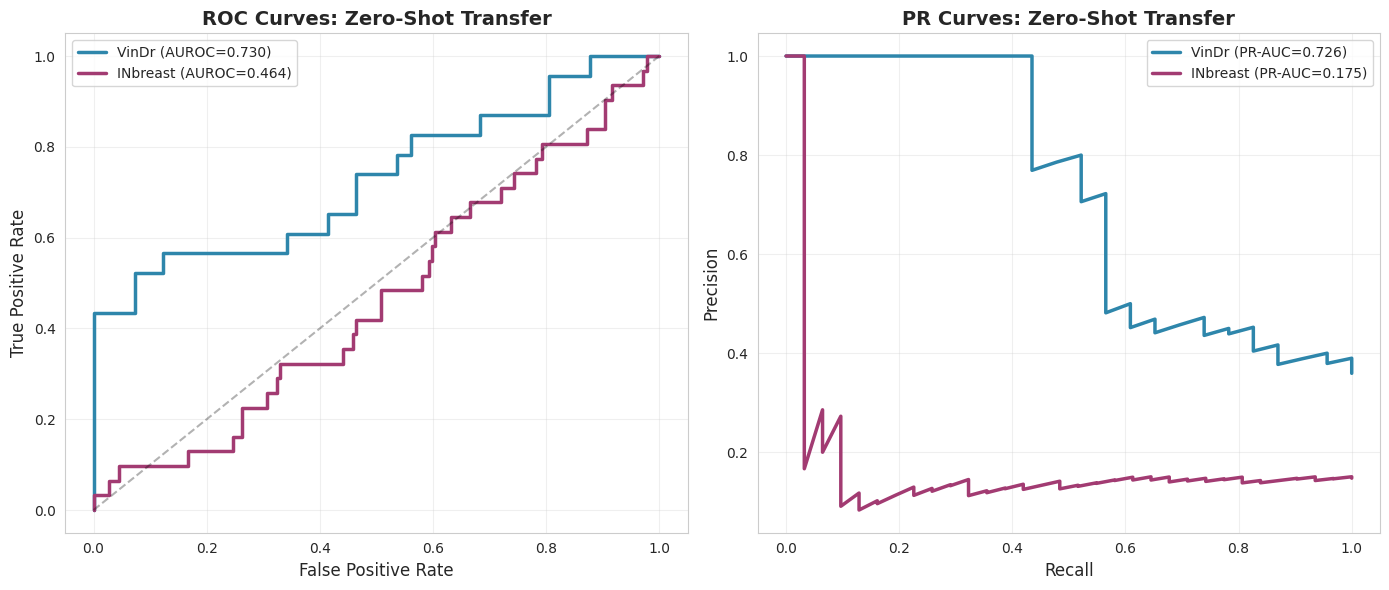

✓ Saved: /kaggle/working/zeroshot_results/zeroshot_curves.png


In [29]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
val_fpr, val_tpr, _ = roc_curve(val_y_true, val_y_probs)
inb_fpr, inb_tpr, _ = roc_curve(inb_y_true, inb_y_probs)

axes[0].plot(val_fpr, val_tpr, label=f'VinDr (AUROC={val_continuous_metrics["auroc"]:.3f})', linewidth=2.5, color='#2E86AB')
axes[0].plot(inb_fpr, inb_tpr, label=f'INbreast (AUROC={inb_continuous_metrics["auroc"]:.3f})', linewidth=2.5, color='#A23B72')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)

axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves: Zero-Shot Transfer', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PR curves
val_prec, val_rec, _ = precision_recall_curve(val_y_true, val_y_probs)
inb_prec, inb_rec, _ = precision_recall_curve(inb_y_true, inb_y_probs)

axes[1].plot(val_rec, val_prec, label=f'VinDr (PR-AUC={val_continuous_metrics["pr_auc"]:.3f})', linewidth=2.5, color='#2E86AB')
axes[1].plot(inb_rec, inb_prec, label=f'INbreast (PR-AUC={inb_continuous_metrics["pr_auc"]:.3f})', linewidth=2.5, color='#A23B72')

axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('PR Curves: Zero-Shot Transfer', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = OUTPUT_DIR / 'zeroshot_curves.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {plot_path}")

## Summary

### ✅ Completed
1. Trained ResNet152 with BoTorch-optimized hyperparameters
2. Selected threshold using Youden's Index (data-driven)
3. Fixed INbreast breast grouping using Patient ID
4. Enabled entropy-based adaptive preprocessing
5. Verified Noisy-OR aggregation is working
6. Compared image-level vs breast-level performance
7. Measured zero-shot generalization gap

### 🔑 Key Findings
- **VinDr validation**: High performance confirms optimization success
- **INbreast zero-shot**: Reveals true generalization capability
- **Noisy-OR impact**: Quantifies benefit of multi-view aggregation
- **Calibration**: Brier score shows probability calibration quality

### 📊 Next Steps
1. Analyze failure cases on INbreast
2. Consider temperature scaling for calibration
3. Compare with other Pareto solutions
4. Investigate view-specific domain shift